In [2]:
## Import necessary modules 
import snapatac2 as snap
import os
import sys
import scanpy as sc
import pandas as pd 
import importlib
import plotly.io as pio
import anndata as ad
import scvi
print("Last run with scvi-tools version:", scvi.__version__)
import numpy as np

/Users/lucascortes/miniconda3/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/lucascortes/miniconda3/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/lucascortes/miniconda3/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/lucascortes/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Last run with scvi-tools version: 1.4.0.post1


In [3]:
## Import fragment file and view result 
WBC048 = snap.pp.import_fragments(
    "/Users/lucascortes/Documents/Pickett/mtscATAC-Seq/2025_049_Sarah_Pickett/WBC048_outs/fragments.tsv.gz",
    chrom_sizes=snap.genome.hg38,  #
    sorted_by_barcode=False,
)
WBC048

AnnData object with n_obs × n_vars = 7138 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

2025-11-24 14:05:56 - INFO - Computing fragment size distribution...


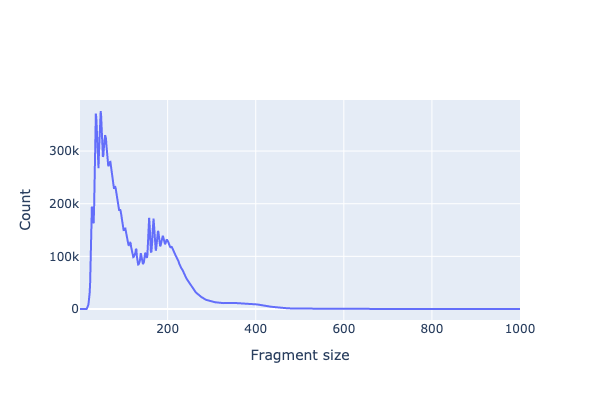

In [4]:
## Bit of extra information:
'''
1. Nucleosome-Free Region (NFR): The majority of fragments are short, typically around 80-300 base pairs (bp) in length. 
These short fragments represent regions of open chromatin where DNA is relatively accessible and not bound to nucleosomes. 
These regions are often referred to as nucleosome-free regions (NFRs) and correspond to regions of active transcriptional 
regulation.

2. Mono-Nucleosome Peaks: There is often a peak in the fragment size distribution at around 147-200 bp, 
which corresponds to the size of a single nucleosome wrapped DNA. These fragments result from the 
cutting of DNA by the transposase enzyme when it encounters a nucleosome, 
causing the DNA to be protected and resulting in fragments of the same size.

3. Di-Nucleosome Peaks: In addition to the mono-nucleosome peak, you may also observe 
a smaller peak at approximately 300-400 bp, corresponding to di-nucleosome fragments. 
These fragments occur when transposase cuts the DNA between two neighboring nucleosomes.

4. Large Fragments: Some larger fragments, greater than 500 bp in size, may be observed. 
These fragments can result from various sources, such as the presence of 
longer stretches of open chromatin or technical artifacts.
'''


snap.pl.frag_size_distr(WBC048, interactive=False)

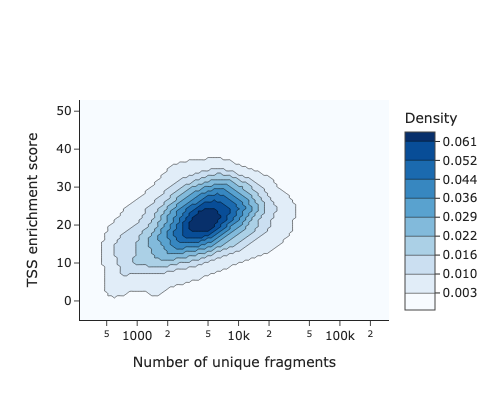

In [5]:
## TSS enrichment implies there is an increased accessibility or fragmentation of chromatin around the TSS
## Often indicative of promoter regions
snap.metrics.tsse(WBC048, snap.genome.hg38)
## To identify usable/high-quality cells, we can plot TSSe scores against number of unique fragments for each cell.
snap.pl.tsse(WBC048, interactive=False)
#MC3

##The cells in the upper right represent valid or high-quality cells, whereas those in the lower left represent low-quality 
# cells or empty droplets. Based on this plot, 
#we decided to set a minimum TSS enrichment of 10 and a minimum number of fragments of 5,000 to filter the cells.

In [6]:
## Option 1 - Filtering cells here results in fewer mitochondrial variants detected
snap.pp.filter_cells(WBC048, min_counts=3000, min_tsse=13, max_counts=100000)
WBC048

AnnData object with n_obs × n_vars = 3891 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [7]:
## Cell by bin matrix containng insertion counts across 500bp bins across the genome
snap.pp.add_tile_matrix(WBC048)

In [8]:
## Feature selection, which will be stored in data.var['selected'] this is particularly relevant for scrublet and spectral
## Selects most accessible features 
## n_features determines number of features, experiment with n_features to find the optimal number for your dataset
snap.pp.select_features(WBC048, n_features=20000)

2025-11-24 14:06:05 - INFO - Selected 20000 features.


In [9]:
## Scrublet is used to remove potential dublets. It will assign probabilities to each cell, and then we can filter
snap.pp.scrublet(WBC048)
snap.pp.filter_doublets(WBC048)
WBC048

2025-11-24 14:06:06 - INFO - Simulating doublets...
2025-11-24 14:06:06 - INFO - Spectral embedding ...
2025-11-24 14:06:09 - INFO - Calculating doublet scores...
2025-11-24 14:06:10 - INFO - Detected doublet rate = 2.313%


AnnData object with n_obs × n_vars = 3801 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile', 'scrublet_sim_doublet_score', 'doublet_rate'
    obsm: 'fragment_paired'

In [10]:
## Spectral embedding is used for dimensionality reduction
## Stored in data.obsm['X_spectral']
snap.tl.spectral(WBC048)
snap.tl.umap(WBC048)

/Users/lucascortes/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [11]:
## Perform graph based clustering, build k-nearest neighbour graph then use leiden algorithm to identify clusters
snap.pp.knn(WBC048)
snap.tl.leiden(WBC048, resolution=0.7)  # Adjust resolution for more or fewer clusters

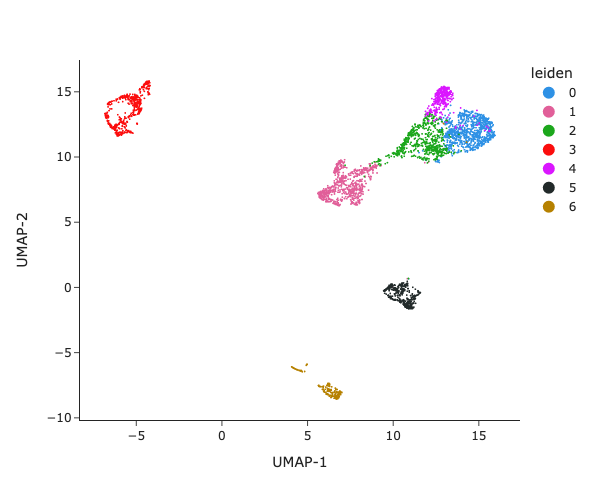

In [12]:
snap.pl.umap(WBC048, color='leiden', interactive=False, height=500)

In [13]:
#Import single cell RNA seq data for label transfer
reference = snap.read(snap.datasets.pbmc10k_multiome(), backed=None)
print(snap.datasets.pbmc10k_multiome())
reference

/Users/lucascortes/Library/Caches/snapatac2/10x-Multiome-Pbmc10k-RNA.h5ad


AnnData object with n_obs × n_vars = 9631 × 29095
    obs: 'domain', 'cell_type'
    var: 'gene_ids', 'feature_types'

In [14]:
#Format our data correctly for label transfer
query = snap.pp.make_gene_matrix(WBC048, gene_anno=snap.genome.hg38)
query

AnnData object with n_obs × n_vars = 3801 × 60606
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden'

In [15]:
## Merge two together and use scanpy library to identify highly variable genes 
query.obs['cell_type'] = pd.NA
data = ad.concat(
    [reference, query],
    join='inner',
    label='batch',
    keys=["reference", "query"],
    index_unique='_',
)
data

/Users/lucascortes/miniconda3/lib/python3.13/site-packages/anndata/_core/merge.py:1664: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



AnnData object with n_obs × n_vars = 13432 × 20169
    obs: 'cell_type', 'batch'

In [16]:
## Finding highly variable genes
sc.pp.filter_genes(data, min_cells=5)
sc.pp.highly_variable_genes(
    data,
    n_top_genes = 5000,
    flavor="seurat_v3",
    batch_key="batch",
    subset=True
)

In [17]:
## Pretrain the scvi-tools model
scvi.model.SCVI.setup_anndata(data, batch_key="batch")
vae = scvi.model.SCVI(
    data,
    n_layers=2,
    n_latent=30,
    gene_likelihood="nb",
    dispersion="gene-batch",
)

In [18]:
vae.train(max_epochs=1000, early_stopping=True)

/Users/lucascortes/miniconda3/lib/python3.13/site-packages/scvi/train/_trainrunner.py:84: UserWarning:

`accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.

INFO: GPU available: True (mps), used: False
2025-11-24 14:06:35 - INFO - GPU available: True (mps), used: False
INFO: TPU available: False, using: 0 TPU cores
2025-11-24 14:06:35 - INFO - TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2025-11-24 14:06:35 - INFO - HPU available: False, using: 0 HPUs
/Users/lucascortes/miniconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:177: PossibleUserWarning:

GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

/Users/lucascortes/miniconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: Possib

Epoch 164/1000:  16%|█▋        | 163/1000 [06:26<35:14,  2.53s/it, v_num=1, train_loss=1.74e+3]

INFO: 
Detected KeyboardInterrupt, attempting graceful shutdown ...
2025-11-24 14:13:03 - INFO - 
Detected KeyboardInterrupt, attempting graceful shutdown ...


Exception raised during training. <class 'NameError'> 1


SystemExit: 1

/Users/lucascortes/miniconda3/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3707: UserWarning:

To exit: use 'exit', 'quit', or Ctrl-D.



<Axes: xlabel='epoch'>

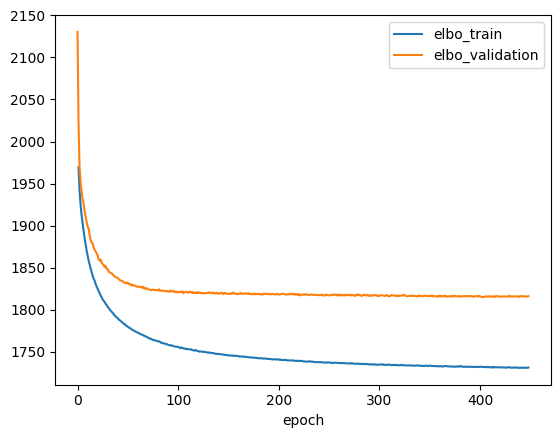

In [ ]:
##Plot training history and make sure the model has converged
ax = vae.history['elbo_train'][1:].plot()
vae.history['elbo_validation'].plot(ax=ax)

In [ ]:
data.obs["celltype_scanvi"] = 'Unknown'
ref_idx = data.obs['batch'] == "reference"
data.obs["celltype_scanvi"][ref_idx] = data.obs['cell_type'][ref_idx]

/var/folders/xk/48p4vmnj5z1g941ty5p14nbc0000gq/T/ipykernel_3647/134013430.py:3: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


/var/folders/xk/48p4vmnj5z1g941ty5p14nbc0000gq/T/ipykernel_3647/134013430.py:3: SettingWithCopyWarning:


A value i

In [ ]:
lvae = scvi.model.SCANVI.from_scvi_model(
    vae,
    adata=data,
    labels_key="celltype_scanvi",
    unlabeled_category="Unknown",
)

In [ ]:
lvae.train(max_epochs=1000, n_samples_per_label=100)


INFO     Training for 1000 epochs.                                                                                 


/Users/lucascortes/miniconda3/lib/python3.13/site-packages/scvi/train/_trainrunner.py:84: UserWarning:

`accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.

INFO: GPU available: True (mps), used: False
2025-11-03 11:48:22 - INFO - GPU available: True (mps), used: False
INFO: TPU available: False, using: 0 TPU cores
2025-11-03 11:48:22 - INFO - TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2025-11-03 11:48:22 - INFO - HPU available: False, using: 0 HPUs
/Users/lucascortes/miniconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:177: PossibleUserWarning:

GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

/Users/lucascortes/miniconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: Possib

Epoch 1000/1000: 100%|██████████| 1000/1000 [1:12:14<00:00,  4.43s/it, v_num=1, train_loss=1.73e+3]

INFO: `Trainer.fit` stopped: `max_epochs=1000` reached.
2025-11-03 13:00:37 - INFO - `Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 1000/1000: 100%|██████████| 1000/1000 [1:12:14<00:00,  4.33s/it, v_num=1, train_loss=1.73e+3]


<Axes: xlabel='epoch'>

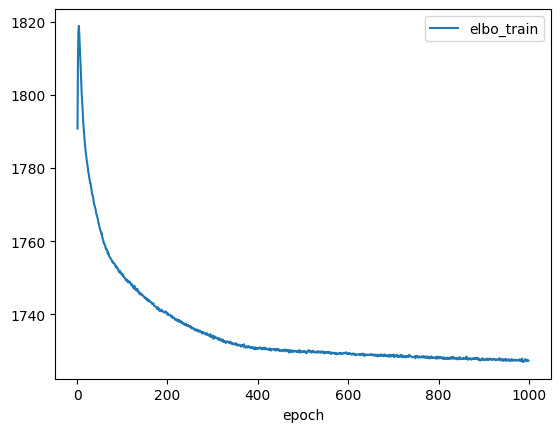

In [ ]:
lvae.history['elbo_train'][1:].plot()

In [ ]:
#Now perform label transfer and the joint embedding of reference and query data
data.obs["C_scANVI"] = lvae.predict(data)
data.obsm["X_scANVI"] = lvae.get_latent_representation(data)
sc.pp.neighbors(data, use_rep="X_scANVI")
sc.tl.umap(data)


/Users/lucascortes/miniconda3/lib/python3.13/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning:

Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.



... storing 'celltype_scanvi' as categorical
... storing 'C_scANVI' as categorical


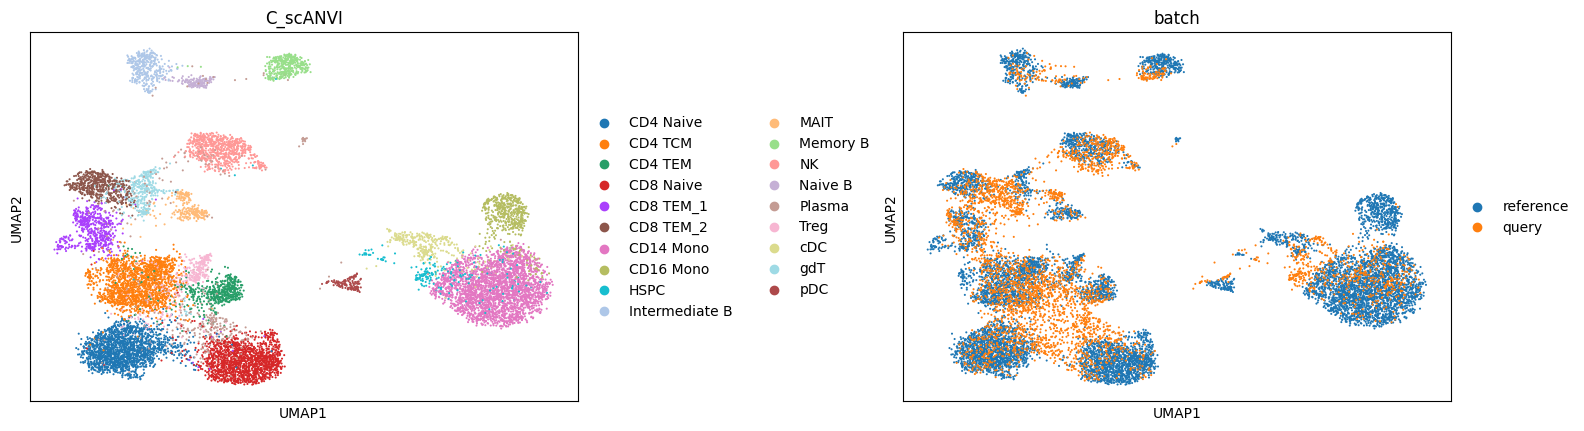

In [ ]:
sc.pl.umap(data, color=['C_scANVI', "batch"], wspace=0.45)

In [ ]:
WBC048.obs['cell_type'] = data.obs.loc[WBC048.obs_names + '_query']['C_scANVI'].to_numpy()

... storing 'leiden' as categorical
... storing 'cell_type' as categorical


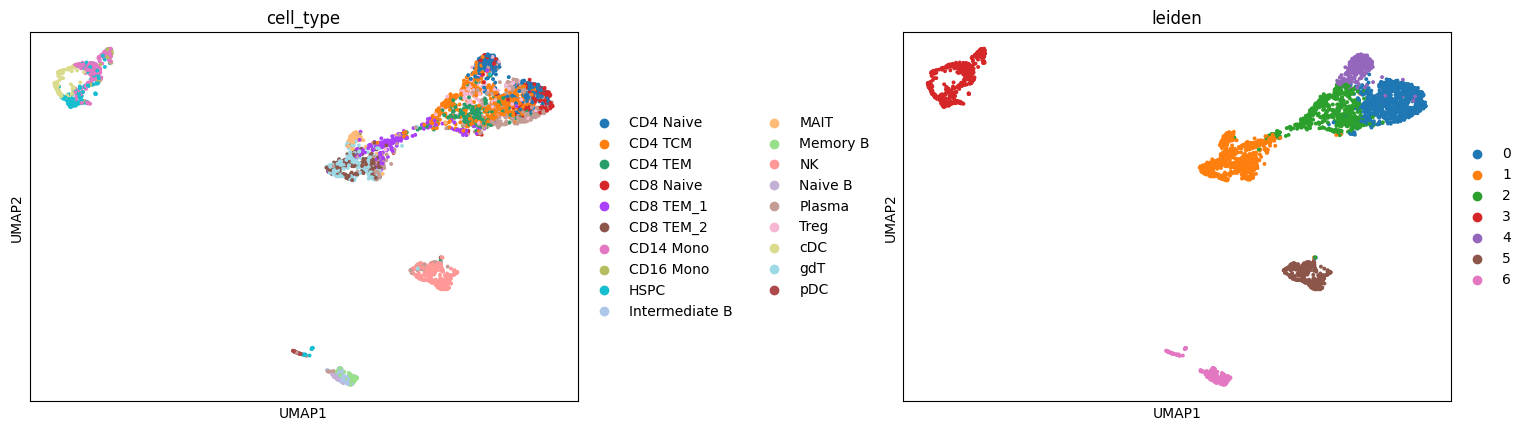

In [ ]:
sc.pl.umap(WBC048, color=['cell_type', "leiden"], wspace=0.45)
WBC048.write("WBC048_annotated.h5ad", compression="gzip")

In [19]:
gene_matrix = snap.pp.make_gene_matrix(WBC048, snap.genome.hg38)
gene_matrix

AnnData object with n_obs × n_vars = 3801 × 60606
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden'

In [20]:
### The cell by gene activity matrix is sparse
## The MAGIC algorithm performs imputation and data smoothing
## Then scanpy does subsequent steps 
## First perform gene filtering, normalisation and transformation and then call MAGIC
sc.pp.filter_genes(gene_matrix, min_cells= 5)
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)
# Skip MAGIC imputation - the analysis will work fine without it
# sc.external.pp.magic(gene_matrix, solver="approximate")

# Copy over UMAP embedding
gene_matrix.obsm["X_umap"] = WBC048.obsm["X_umap"]
gene_matrix

AnnData object with n_obs × n_vars = 3801 × 51186
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden'
    var: 'n_cells'
    uns: 'log1p'
    obsm: 'X_umap'

In [21]:
sys.path.insert(0, '/Users/lucascortes/Library/CloudStorage/OneDrive-Personal/Documents/Work/Pickett/ATAC-Seq/Py-mTCall')
import Py_mTCall_tools.variant_calling_fast as vc

importlib.reload(vc)

mgatk = vc.process_variants_fast(
        "/Users/lucascortes/Documents/Pickett/mtscATAC-Seq/2025_049_Sarah_Pickett/WBC048_test/final", 
        gene_matrix, coverage_threshold=20
    )


=== Fast Variant Calling Pipeline ===
Loaded counts data: (132067, 6460)
Loaded coverage data: (106352154, 3)
Identifying variants (memory-optimized chunked method)...
Processing all 98931 variant observations (no artificial limits)
Integrating with AnnData...
=== Pipeline Complete ===
Processed 6630 variants in 3801 matching cells


/var/folders/xk/48p4vmnj5z1g941ty5p14nbc0000gq/T/ipykernel_53812/4245680750.py:21: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



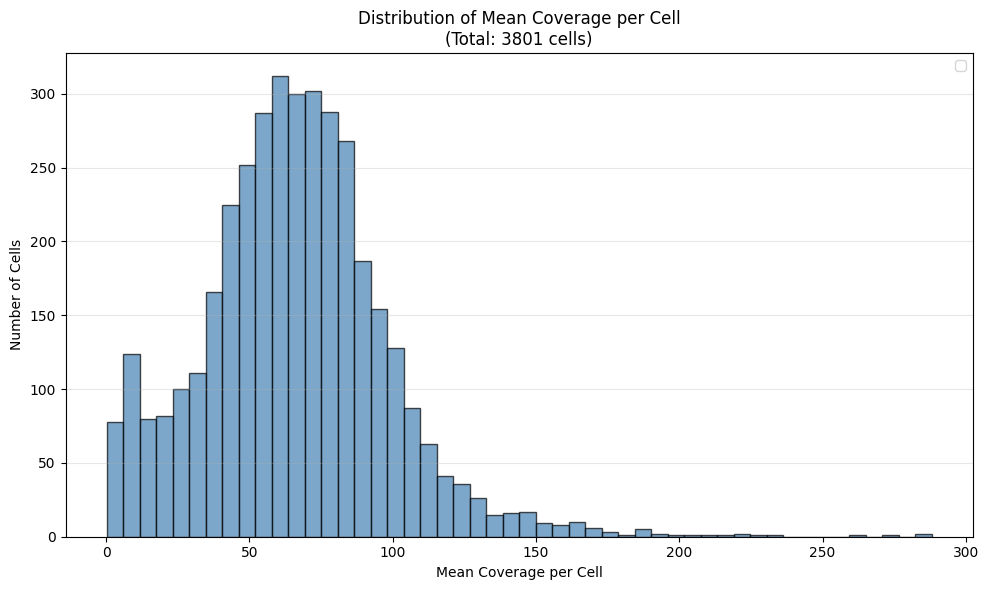

=== MEAN COVERAGE PER CELL STATISTICS ===
Total cells: 3801
Overall mean coverage per cell: 65.93
Median coverage per cell: 65.28
Standard deviation: 32.32
Min coverage per cell: 0.30
Max coverage per cell: 288.04
25th percentile: 45.94
75th percentile: 83.74


In [22]:
# Plot mean coverage per cell - Fixed version with coverage on X-axis
import matplotlib.pyplot as plt
import numpy as np

# Get the coverage matrix (cells x variants)
coverage_matrix = mgatk.obsm['variant_coverage']

# Calculate mean coverage per cell across all variants
mean_coverage_per_cell = coverage_matrix.mean(axis=1)

# Create a single histogram plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Histogram with coverage on x-axis and number of cells on y-axis
ax.hist(mean_coverage_per_cell, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax.set_xlabel('Mean Coverage per Cell')
ax.set_ylabel('Number of Cells')
ax.set_title(f'Distribution of Mean Coverage per Cell\n(Total: {len(mean_coverage_per_cell)} cells)')


ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"=== MEAN COVERAGE PER CELL STATISTICS ===")
print(f"Total cells: {len(mean_coverage_per_cell)}")
print(f"Overall mean coverage per cell: {mean_coverage_per_cell.mean():.2f}")
print(f"Median coverage per cell: {np.median(mean_coverage_per_cell):.2f}")
print(f"Standard deviation: {mean_coverage_per_cell.std():.2f}")
print(f"Min coverage per cell: {mean_coverage_per_cell.min():.2f}")
print(f"Max coverage per cell: {mean_coverage_per_cell.max():.2f}")
print(f"25th percentile: {np.percentile(mean_coverage_per_cell, 25):.2f}")
print(f"75th percentile: {np.percentile(mean_coverage_per_cell, 75):.2f}")

In [23]:
# Plot confident variants with UMAP and VAF distribution
import matplotlib.pyplot as plt
import numpy as np

# Get confident variants (those with at least one cell having confident detection)
confident_variants = mgatk.uns['variant_summary'][mgatk.uns['variant_summary']['n_cells_conf_detected'] > 2]

print(f"Plotting first 5 confident variants out of {len(confident_variants)} total confident variants")
print(mgatk.uns['variant_summary'].head())

# Get the variant names list
variant_names = mgatk.uns['variant_names']

for i, variant_idx in enumerate(confident_variants.index[:20]):  # Plot top 5 confident variants
    # variant_idx is already the integer index we need
    variant_name = variant_names[variant_idx]  # Get the actual variant name string
    
    print(f"Processing variant {i+1}: Index {variant_idx}, Name: {variant_name}")
    
    # Get VAF and confident matrices
    vaf_matrix = mgatk.obsm['variant_vaf']
    confident_matrix = mgatk.obsm['variant_confident']
    
    # Extract VAF and confidence for this specific variant using the integer index
    vaf_values = vaf_matrix[:, variant_idx]
    confident_calls = confident_matrix[:, variant_idx]
    
    # Filter for confident calls AND non-zero VAF
    confident_and_nonzero_mask = confident_calls & (vaf_values >= 30)
    
    if not confident_and_nonzero_mask.any():
        print(f"No confident non-zero calls for variant {variant_name}")
        continue
    
    # Get filtered VAF values
    filtered_vaf_values = vaf_values[confident_and_nonzero_mask]
    
    # Create a temporary column for plotting (confident calls only)
    temp_vaf_col = np.zeros(len(mgatk.obs))
    temp_vaf_col[confident_and_nonzero_mask] = filtered_vaf_values
    # Set non-confident or zero calls to NaN for proper plotting
    temp_vaf_col[~confident_and_nonzero_mask] = np.nan
    
    # Add temporary column to obs for plotting
    mgatk.obs[f'temp_vaf_{variant_idx}'] = temp_vaf_col
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # UMAP plot (only confident calls will be colored)
    sc.pl.umap(mgatk, color=f'temp_vaf_{variant_idx}', cmap="viridis", vmin=0, vmax=1, 
               title=f"Confident VAF for {variant_name}\n(Confident cells: {confident_variants.loc[variant_idx, 'n_cells_conf_detected']})", 
               ax=ax1, show=False, na_color='lightgray')
    
    # Histogram of confident VAF values only
    ax2.hist(filtered_vaf_values, bins=30, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('VAF (Variant Allele Frequency)')
    ax2.set_ylabel('Number of Cells (Confident Calls Only)')
    ax2.set_title(f'Confident VAF Distribution for {variant_name}')
    ax2.axvline(filtered_vaf_values.mean(), color='red', linestyle='--', 
                label=f'Mean: {filtered_vaf_values.mean():.3f}')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    total_cells = len(mgatk.obs)
    confident_cells = confident_calls.sum()
    confident_nonzero_cells = len(filtered_vaf_values)
    
    print(f"Variant {variant_name} (Index {variant_idx}):")
    print(f"  Confident cells detected: {confident_variants.loc[variant_idx, 'n_cells_conf_detected']}")
    print(f"  Mean coverage: {confident_variants.loc[variant_idx, 'mean_coverage']:.1f}")
    print(f"  Total cells: {total_cells}")
    print(f"  Confident calls: {confident_calls}")
    print(f"  Confident non-zero calls: {confident_nonzero_cells}")
    print(f"  Mean confident VAF: {filtered_vaf_values.mean():.3f}")
    print(f"  Confident VAF range: {filtered_vaf_values.min():.3f} - {filtered_vaf_values.max():.3f}")
    print("---")
    
    # Clean up temporary column
    mgatk.obs.drop(columns=[f'temp_vaf_{variant_idx}'], inplace=True)

Plotting first 5 confident variants out of 1153 total confident variants
       variance  n_cells_conf_detected  n_cells_over_5  n_cells_over_10  \
0  3.969792e-07                      1               1                0   
1  6.144329e-07                      1               1                0   
2  1.553643e-04                      2               2                1   
3  4.649178e-07                      1               1                0   
4  1.602609e-06                      5               1                0   

   n_cells_over_50  mean_coverage  strand_concordance  vaf_overall  
0                0      77.356357            1.000000     0.000008  
1                0      70.954933            1.000000     0.000017  
2                1      56.119405            0.984524     0.000141  
3                0      79.349698            0.850309     0.000008  
4                0      73.210469            0.988372     0.000042  
Processing variant 1: Index 4, Name: A-11232-T
No confident no

Variant A-11232-T: Insufficient data points (4)


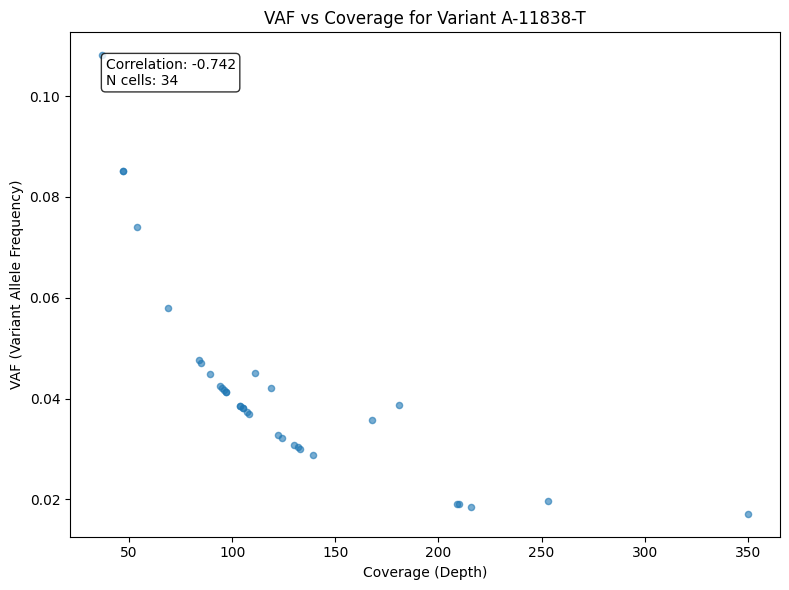

Variant A-11838-T:
  Coverage range: 37.0 - 350.0
  Mean coverage: 124.1
  VAF range: 0.017 - 0.108
  Correlation (VAF vs Coverage): -0.742
---
Variant A-12164-G: Insufficient data points (2)
Variant A-1253-C: Insufficient data points (3)
Variant A-12622-G: Insufficient data points (4)
Variant A-14364-G: Insufficient data points (2)
Variant A-1509-T: Insufficient data points (2)
Variant A-1669-G: Insufficient data points (1)
Variant A-2009-G: Insufficient data points (5)


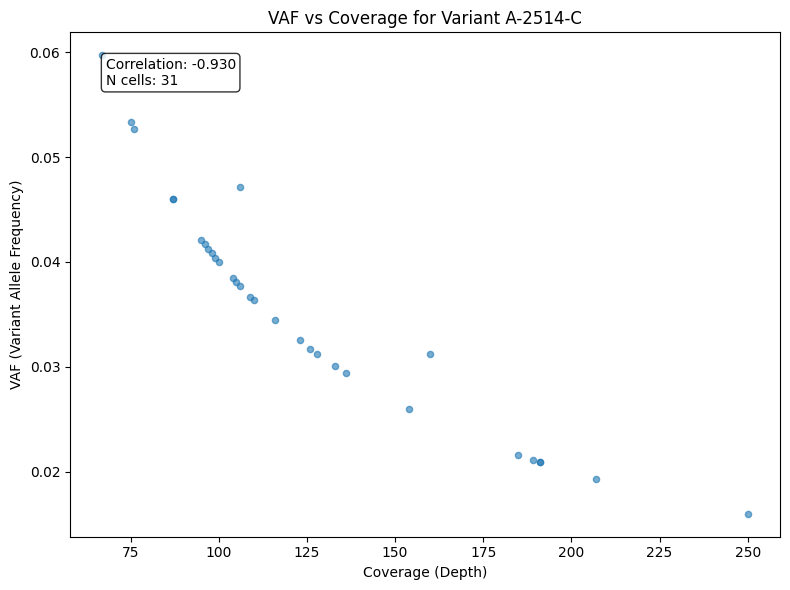

Variant A-2514-C:
  Coverage range: 67.0 - 250.0
  Mean coverage: 126.0
  VAF range: 0.016 - 0.060
  Correlation (VAF vs Coverage): -0.930
---
Variant A-2553-G: Insufficient data points (2)


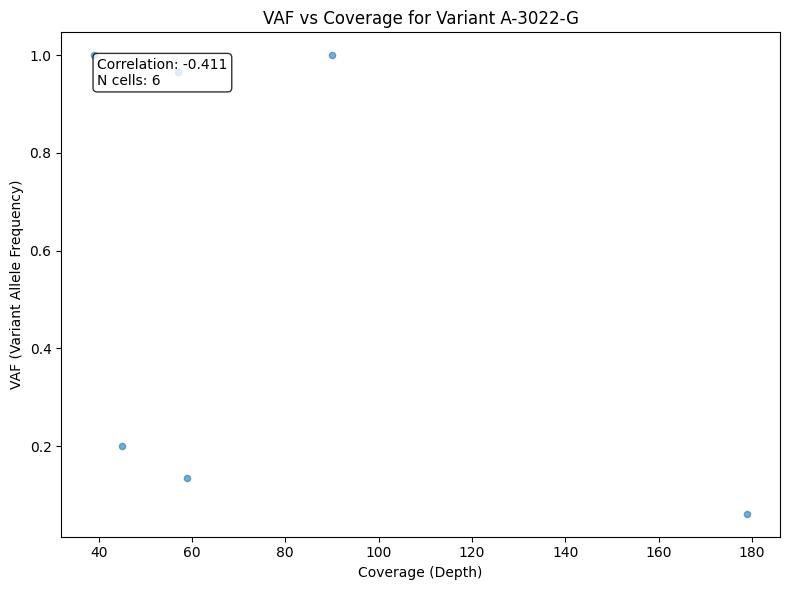

Variant A-3022-G:
  Coverage range: 39.0 - 179.0
  Mean coverage: 78.2
  VAF range: 0.061 - 1.000
  Correlation (VAF vs Coverage): -0.411
---
Variant A-3472-T: Insufficient data points (2)
Variant A-3850-G: Insufficient data points (3)
Variant A-4100-T: Insufficient data points (2)
Variant A-541-C: Insufficient data points (2)
Variant A-545-G: Insufficient data points (1)
Variant A-6427-C: Insufficient data points (1)


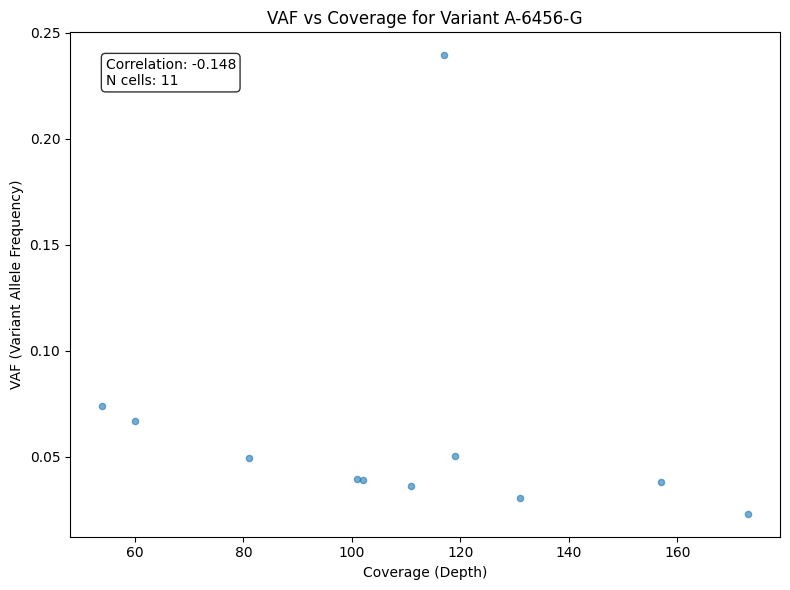

Variant A-6456-G:
  Coverage range: 54.0 - 173.0
  Mean coverage: 109.6
  VAF range: 0.023 - 0.239
  Correlation (VAF vs Coverage): -0.148
---
Variant A-6466-T: Insufficient data points (2)
Variant A-7235-C: Insufficient data points (3)


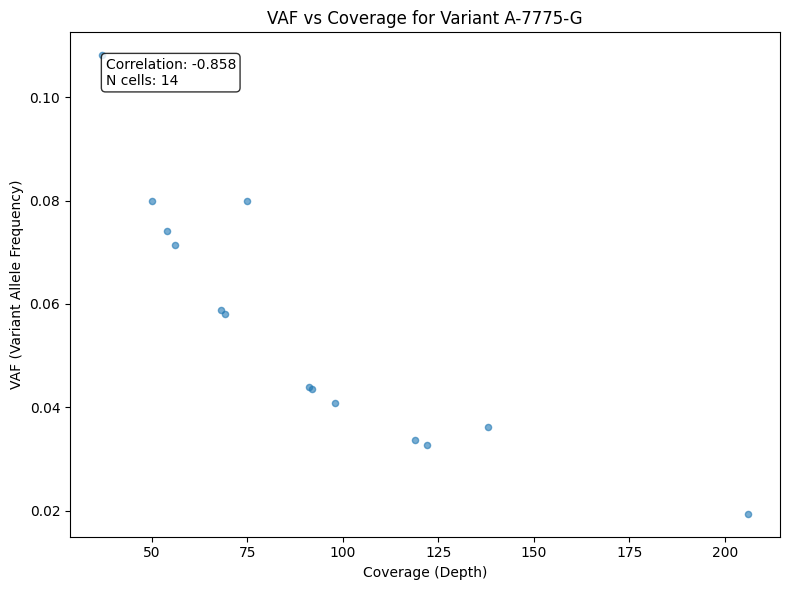

Variant A-7775-G:
  Coverage range: 37.0 - 206.0
  Mean coverage: 91.1
  VAF range: 0.019 - 0.108
  Correlation (VAF vs Coverage): -0.858
---
Variant A-8092-C: Insufficient data points (3)
Variant A-9266-G: Insufficient data points (2)
Variant C-1016-T: Insufficient data points (4)
Variant C-10953-T: Insufficient data points (3)
Variant C-10989-T: Insufficient data points (1)
Variant C-11009-T: Insufficient data points (1)
Variant C-11505-T: Insufficient data points (2)
Variant C-11877-T: Insufficient data points (1)
Variant C-12101-T: Insufficient data points (5)
Variant C-12117-T: Insufficient data points (3)
Variant C-12121-T: Insufficient data points (3)
Variant C-12522-T: Insufficient data points (5)
Variant C-12586-T: Insufficient data points (2)
Variant C-12758-T: Insufficient data points (1)
Variant C-12811-T: Insufficient data points (4)
Variant C-12898-T: Insufficient data points (1)
Variant C-13015-T: Insufficient data points (3)
Variant C-13030-T: Insufficient data points (

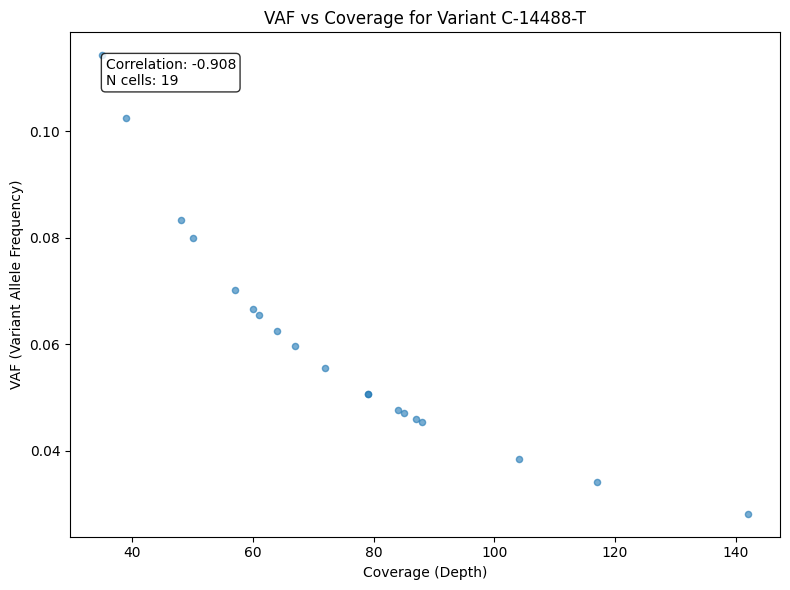

Variant C-14488-T:
  Coverage range: 35.0 - 142.0
  Mean coverage: 74.6
  VAF range: 0.028 - 0.114
  Correlation (VAF vs Coverage): -0.908
---
Variant C-14868-T: Insufficient data points (3)
Variant C-15149-T: Insufficient data points (1)
Variant C-15541-T: Insufficient data points (3)


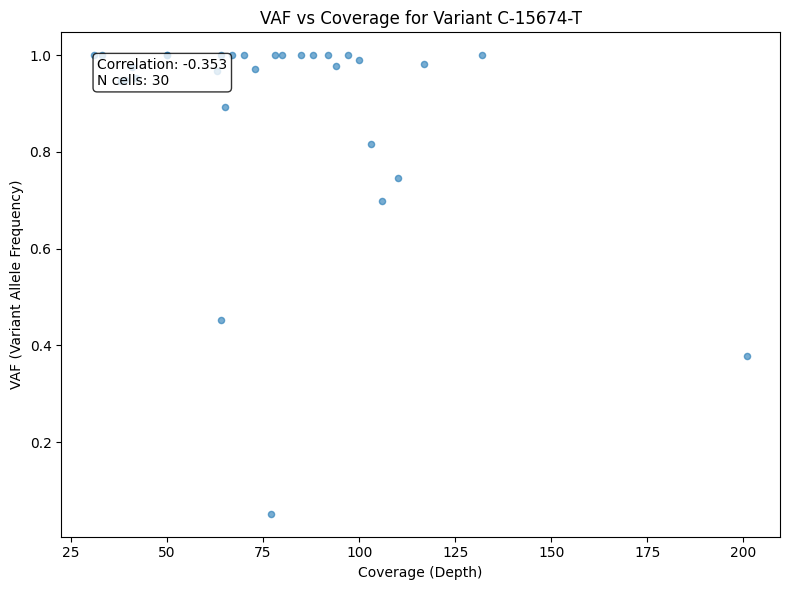

Variant C-15674-T:
  Coverage range: 31.0 - 201.0
  Mean coverage: 78.3
  VAF range: 0.052 - 1.000
  Correlation (VAF vs Coverage): -0.353
---
Variant C-15822-T: Insufficient data points (1)


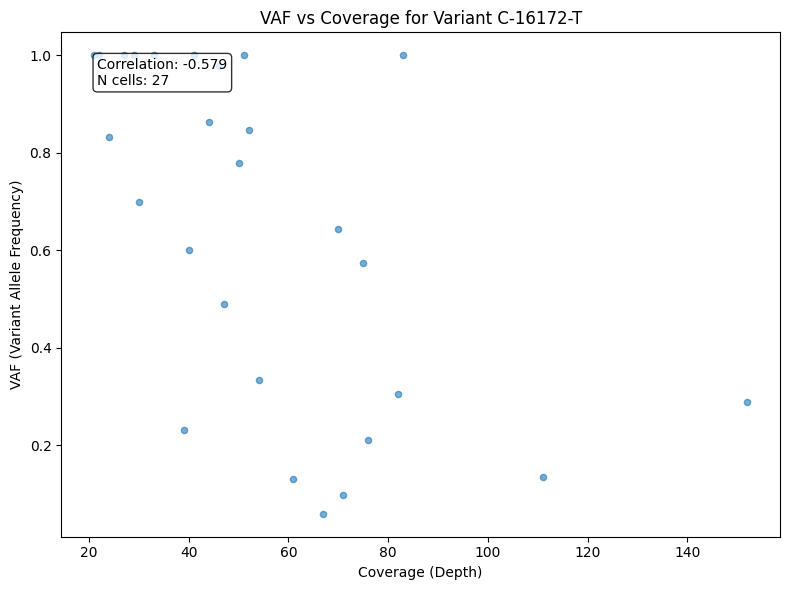

Variant C-16172-T:
  Coverage range: 21.0 - 152.0
  Mean coverage: 55.5
  VAF range: 0.060 - 1.000
  Correlation (VAF vs Coverage): -0.579
---


In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Get the matrices and variant info
vaf_matrix = mgatk.obsm['variant_vaf']        # cells x variants
coverage_matrix = mgatk.obsm['variant_coverage']  # cells x variants  
variant_names = mgatk.uns['variant_names']

# For variants in your confident_variants
for i, variant_idx in enumerate(confident_variants.index[:50]):  # Plot top 5 confident variants
    # variant_idx is already the integer index we need
    variant_name = variant_names[variant_idx]  # Get the actual variant name string
    try:
        variant_idx = confident_variants.index[i]  # Get the actual variant index
        # Find the index of this variant in the variant_names list
        variant_idx = variant_names.index(variant_name)
        
        # Get VAF and coverage values for this variant across all cells
        vaf_values = vaf_matrix[:, variant_idx]
        coverage_values = coverage_matrix[:, variant_idx]
        
        # Filter for cells with non-zero VAF and valid coverage
        mask = (vaf_values > 0.01) & (coverage_values > 20)
        
        if mask.sum() > 5:  # Need at least 5 points for meaningful plot
            filtered_vaf = vaf_values[mask]
            filtered_coverage = coverage_values[mask]
            
            # Create scatter plot
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            
            scatter = ax.scatter(filtered_coverage, filtered_vaf, alpha=0.6, s=20)
            ax.set_xlabel('Coverage (Depth)')
            ax.set_ylabel('VAF (Variant Allele Frequency)')
            ax.set_title(f'VAF vs Coverage for Variant {variant_name}')
            
            # Add statistics
            if len(filtered_coverage) > 1 and len(set(filtered_coverage)) > 1:
                correlation = np.corrcoef(filtered_coverage, filtered_vaf)[0, 1]
            else:
                correlation = np.nan
                
            ax.text(0.05, 0.95, f'Correlation: {correlation:.3f}\nN cells: {len(filtered_vaf)}', 
                    transform=ax.transAxes, verticalalignment='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            plt.tight_layout()
            plt.show()
            
            # Print summary
            print(f"Variant {variant_name}:")
            print(f"  Coverage range: {filtered_coverage.min():.1f} - {filtered_coverage.max():.1f}")
            print(f"  Mean coverage: {filtered_coverage.mean():.1f}")
            print(f"  VAF range: {filtered_vaf.min():.3f} - {filtered_vaf.max():.3f}")
            print(f"  Correlation (VAF vs Coverage): {correlation:.3f}")
            print("---")
        else:
            print(f"Variant {variant_name}: Insufficient data points ({mask.sum()})")
            
    except Exception as e:
        print(f"Error processing variant {variant_name}: {e}")


In [25]:
mgatk.write("mgatk_annotated.h5ad", compression="gzip")

... storing 'leiden' as categorical


In [26]:
import anndata as ad
#mgatk = ad.read_h5ad("mgatk_annotated.h5ad")

In [27]:
import numpy as np
import pandas as pd

# Get the matrices
vaf_matrix = mgatk.obsm['variant_vaf'].copy()  # Make a copy to modify
coverage_matrix = mgatk.obsm['variant_coverage']
confident_matrix = mgatk.obsm['variant_confident']
variant_names = mgatk.uns['variant_names']
variant_summary = mgatk.uns['variant_summary']

print(f"Original VAF matrix shape: {vaf_matrix.shape}")
print(f"Non-zero VAF values before filtering: {(vaf_matrix > 0).sum()}")

# Count variants with at least one expressing cell before filtering
variants_with_expression_before = (vaf_matrix > 0).any(axis=0).sum()
print(f"Variants with at least one expressing cell before filtering: {variants_with_expression_before}")

# Create high-quality filtered VAF matrix
high_quality_vaf_matrix = vaf_matrix.copy()
variant_names_list = []
# For each variant, apply cell-level quality filters
for i, variant_name in enumerate(variant_names):
    # Get variant-level statistics
    variant_stats = variant_summary.iloc[i]
    strand_concordance = variant_stats['strand_concordance']
    variance = variant_stats['variance'] 
    mean_coverage = variant_stats['mean_coverage']
    n_cells_over_5 = variant_stats['n_cells_over_5']
    
    # Get cell-level data for this variant
    cell_vaf = vaf_matrix[:, i]
    cell_coverage = coverage_matrix[:, i]
    cell_confident = confident_matrix[:, i]
    
    # Define quality criteria for this variant's cells
    quality_mask = (
        (strand_concordance >= 0.5) &  # Variant-level criterion
        (cell_coverage >= 30) &        # Cell-level criterion
        (mean_coverage >= 30) &
        (n_cells_over_5 >=10)      # Cell-level: VAF > 10%
    )
    
    # Set non-qualifying cells to 0 for this variant
    high_quality_vaf_matrix[~quality_mask, i] = 0

print(f"Non-zero VAF values after high-quality filtering: {(high_quality_vaf_matrix > 0).sum()}")
print(f"Percentage of calls retained: {(high_quality_vaf_matrix > 0).sum() / (vaf_matrix > 0).sum() * 100:.1f}%")

# Count variants with at least one expressing cell after filtering
variants_with_expression_after = (high_quality_vaf_matrix > 0).any(axis=0).sum()
print(f"Variants with at least one expressing cell after filtering: {variants_with_expression_after}")
print(f"Percentage of variants retained: {variants_with_expression_after / variants_with_expression_before * 100:.1f}%")

# Count variants completely eliminated by filtering
variants_eliminated = variants_with_expression_before - variants_with_expression_after
print(f"Variants completely eliminated by filtering: {variants_eliminated}")
print("variants left" , variants_with_expression_after)
# Store the high-quality filtered matrix
mgatk.obsm['variant_vaf_high_quality'] = high_quality_vaf_matrix

# Now you can use this filtered matrix for analysis
print("\nHigh-quality filtered VAF matrix stored in mgatk.obsm['variant_vaf_high_quality']")

Original VAF matrix shape: (3801, 6630)
Non-zero VAF values before filtering: 34603
Variants with at least one expressing cell before filtering: 4506
Non-zero VAF values after high-quality filtering: 24444
Percentage of calls retained: 70.6%
Variants with at least one expressing cell after filtering: 50
Percentage of variants retained: 1.1%
Variants completely eliminated by filtering: 4456
variants left 50

High-quality filtered VAF matrix stored in mgatk.obsm['variant_vaf_high_quality']


In [28]:
variant_name = "G-3243-A"
if variant_name in mgatk.uns['variant_names']:
    print(f"Variant {variant_name} exists in mgatk!")
else:
    print(f"Variant {variant_name} not found.")

Variant G-3243-A exists in mgatk!


Processing variant 6630: Index 6583, Name: G-3243-A
506


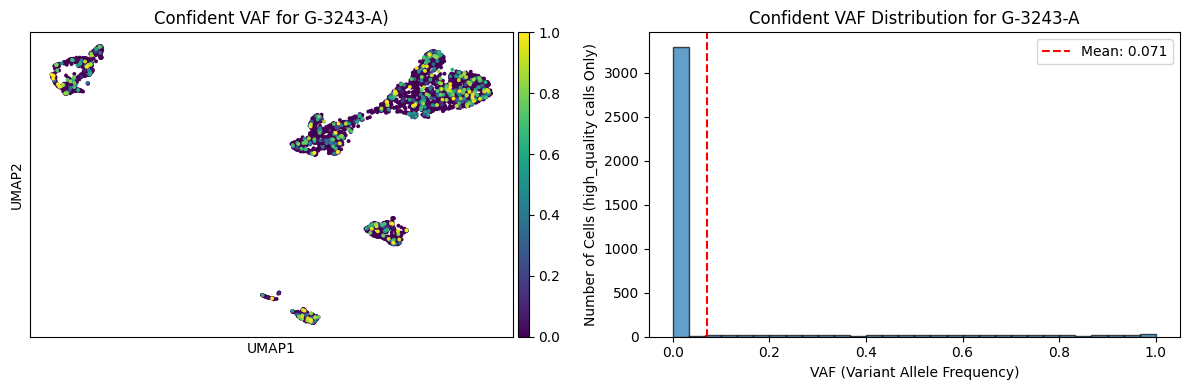

In [29]:
## Plotting 3243
variant_name = 'G-3243-A'  # Get the actual variant name string
variant_idx = mgatk.uns['variant_names'].index(variant_name)

print(f"Processing variant {i+1}: Index {variant_idx}, Name: {variant_name}")

# Get VAF and confident matrices
vaf_matrix = mgatk.obsm['variant_vaf_high_quality']


# Extract VAF and confidence for this specific variant using the integer index
vaf_values = mgatk.obsm['variant_vaf_high_quality'][:, variant_idx]

print(np.sum(vaf_values > 0))



# Get filtered VAF values
filtered_vaf_values = vaf_values

# Create a temporary column for plotting (confident calls only)
temp_vaf_col = np.zeros(len(mgatk.obs))
temp_vaf_col = filtered_vaf_values


# Add temporary column to obs for plotting
mgatk.obs[f'temp_vaf_{variant_idx}'] = temp_vaf_col

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# UMAP plot (only confident calls will be colored)
sc.pl.umap(mgatk, color=f'temp_vaf_{variant_idx}', cmap="viridis", vmin=0, vmax=1, 
            title=f"Confident VAF for {variant_name})", 
            ax=ax1, show=False, na_color='lightgray')

# Histogram of confident VAF values only
ax2.hist(filtered_vaf_values, bins=30, alpha=0.7, edgecolor='black')
ax2.set_xlabel('VAF (Variant Allele Frequency)')
ax2.set_ylabel('Number of Cells (high_quality calls Only)')
ax2.set_title(f'Confident VAF Distribution for {variant_name}')
ax2.axvline(filtered_vaf_values.mean(), color='red', linestyle='--', 
            label=f'Mean: {filtered_vaf_values.mean():.3f}')
ax2.legend()

plt.tight_layout()
plt.show()

Processing variant 6630: Index 6583, Name: G-3243-A
506


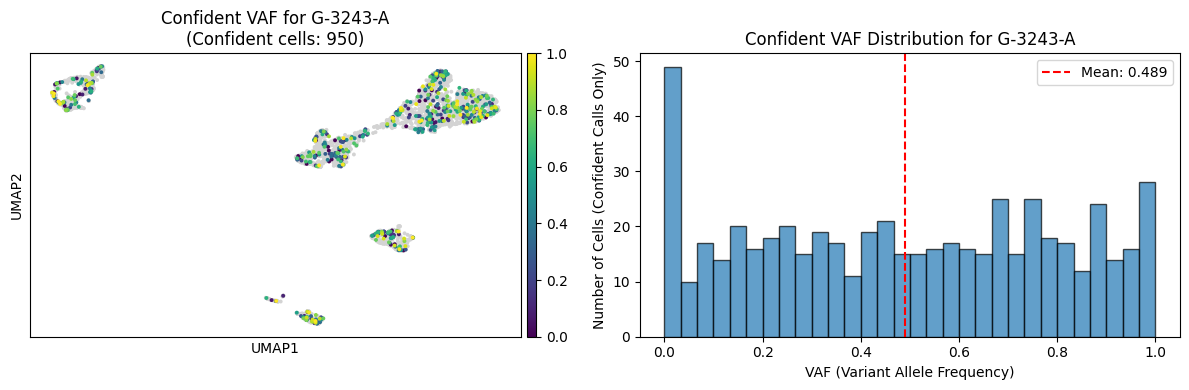

In [30]:
# variant_idx is already the integer index we need
variant_name = 'G-3243-A' # Get the actual variant name string

print(f"Processing variant {i+1}: Index {variant_idx}, Name: {variant_name}")

# Get VAF and confident matrices
vaf_matrix = mgatk.obsm['variant_vaf_high_quality']
confident_matrix = mgatk.obsm['variant_confident']

# Extract VAF and confidence for this specific variant using the integer index
vaf_values = vaf_matrix[:, 6583]
confident_calls = confident_matrix[:, 6583]
print(np.sum(vaf_values > 0))

# Filter for confident calls AND non-zero VAF
confident_and_nonzero_mask = confident_calls & (vaf_values >= 0)


# Get filtered VAF values
filtered_vaf_values = vaf_values[confident_and_nonzero_mask]

# Create a temporary column for plotting (confident calls only)
temp_vaf_col = np.zeros(len(mgatk.obs))
temp_vaf_col[confident_and_nonzero_mask] = filtered_vaf_values
# Set non-confident or zero calls to NaN for proper plotting
temp_vaf_col[~confident_and_nonzero_mask] = np.nan

# Add temporary column to obs for plotting
mgatk.obs[f'temp_vaf_{variant_idx}'] = temp_vaf_col

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# UMAP plot (only confident calls will be colored)
sc.pl.umap(mgatk, color=f'temp_vaf_{6583}', cmap="viridis", vmin=0, vmax=1, 
            title=f"Confident VAF for {variant_name}\n(Confident cells: {confident_variants.loc[6583, 'n_cells_conf_detected']})", 
            ax=ax1, show=False, na_color='lightgray')

# Histogram of confident VAF values only
ax2.hist(filtered_vaf_values, bins=30, alpha=0.7, edgecolor='black')
ax2.set_xlabel('VAF (Variant Allele Frequency)')
ax2.set_ylabel('Number of Cells (Confident Calls Only)')
ax2.set_title(f'Confident VAF Distribution for {variant_name}')
ax2.axvline(filtered_vaf_values.mean(), color='red', linestyle='--', 
            label=f'Mean: {filtered_vaf_values.mean():.3f}')
ax2.legend()

plt.tight_layout()
plt.show()

In [31]:
variants_3243 = [v for v in variant_names if "-3243-" in v]
print(variants_3243)

['G-3243-A', 'T-3243-A']


In [32]:
print(mgatk.uns['variant_summary']['vaf_overall'].loc[6583])


0.07849865579205981


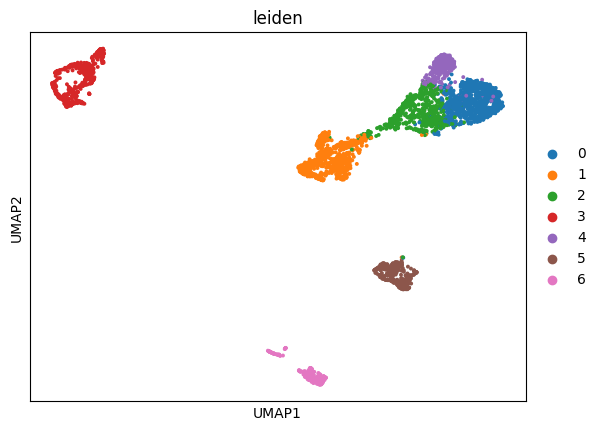

In [33]:
sc.pl.umap(mgatk, color = 'leiden', wspace=0.45)

... storing 'cell_type_manual' as categorical


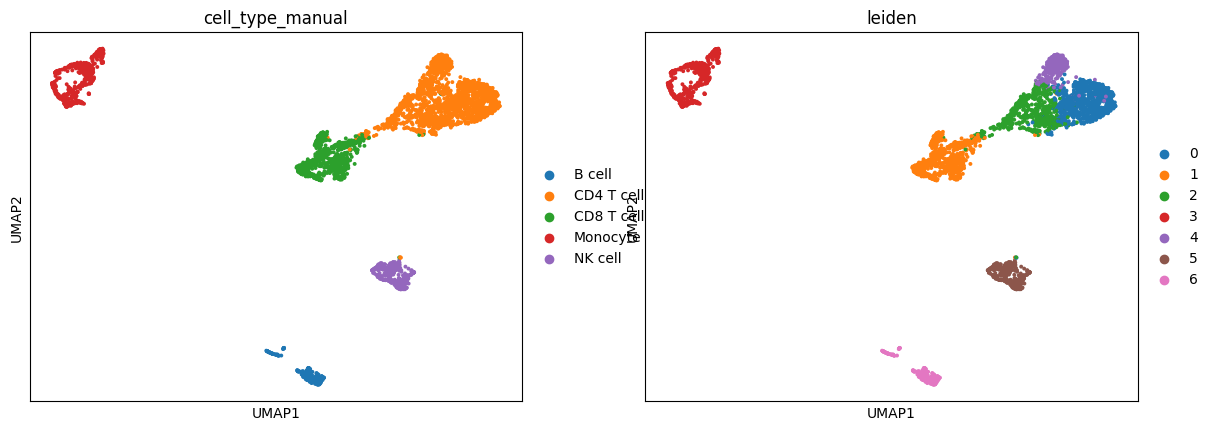

In [34]:
# Define your mapping from cluster to cell type
cluster_to_celltype = {
    '0': 'CD4 T cell',
    '1': 'CD8 T cell',
    '2': 'CD4 T cell',
    '3': 'Monocyte',
    '4': 'CD4 T cell',
    '5': 'NK cell',
    '6': 'B cell',
    # Add more mappings as needed
}

# Map cluster labels to cell types
mgatk.obs['cell_type_manual'] = mgatk.obs['leiden'].map(cluster_to_celltype)

# Now you can plot with cell_type_manual
sc.pl.umap(mgatk, color=['cell_type_manual', 'leiden'])

... storing 'leiden' as categorical
... storing 'cell_type_manual' as categorical


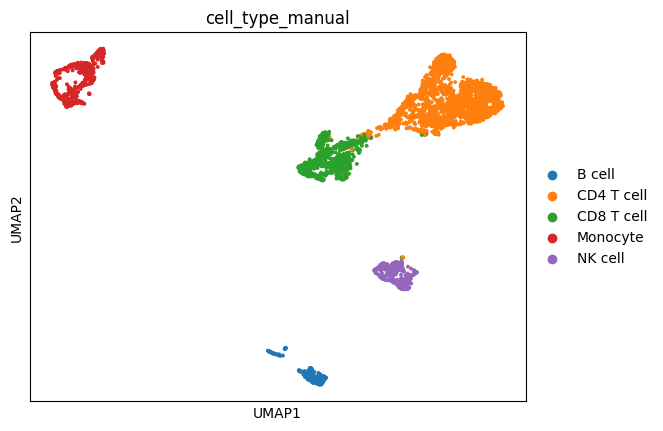

In [35]:
# Define your mapping from cluster to cell type
cluster_to_celltype = {
    '0': 'CD4 T cell',
    '1': 'CD8 T cell',
    '2': 'CD4 T cell',
    '3': 'Monocyte',
    '4': 'CD4 T cell',
    '5': 'NK cell',
    '6': 'B cell',
    # Add more mappings as needed
}

# Map cluster labels to cell types
WBC048.obs['cell_type_manual'] = WBC048.obs['leiden'].map(cluster_to_celltype)

# Now you can plot with cell_type_manual
sc.pl.umap(WBC048, color=['cell_type_manual'])

In [36]:
print(WBC048.obs['cell_type_manual'].value_counts())
print(mgatk.obs['cell_type_manual'].value_counts())

cell_type_manual
CD4 T cell    1926
CD8 T cell     741
Monocyte       546
NK cell        360
B cell         228
Name: count, dtype: int64
cell_type_manual
CD4 T cell    1926
CD8 T cell     741
Monocyte       546
NK cell        360
B cell         228
Name: count, dtype: int64


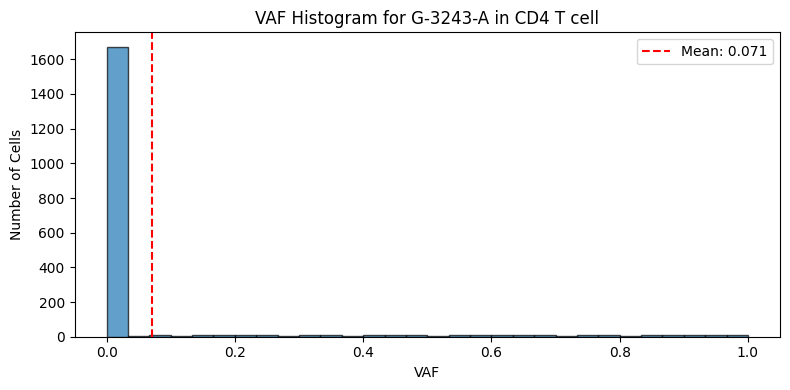

Cell type: CD4 T cell
  Mean VAF: 0.071
  Median VAF: 0.000
  Min VAF: 0.000
  Max VAF: 1.000
  Number of cells: 1926


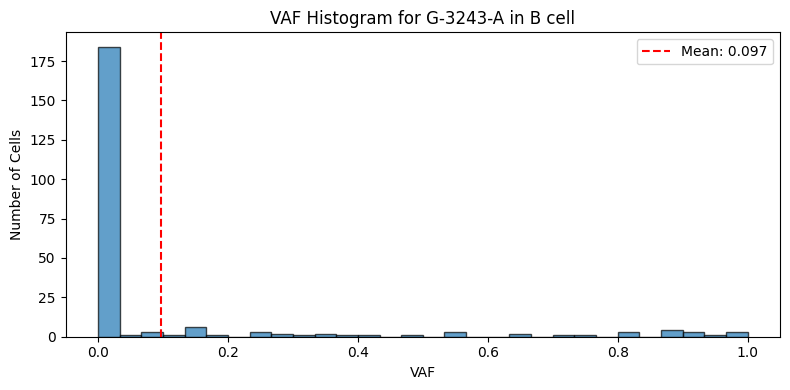

Cell type: B cell
  Mean VAF: 0.097
  Median VAF: 0.000
  Min VAF: 0.000
  Max VAF: 1.000
  Number of cells: 228


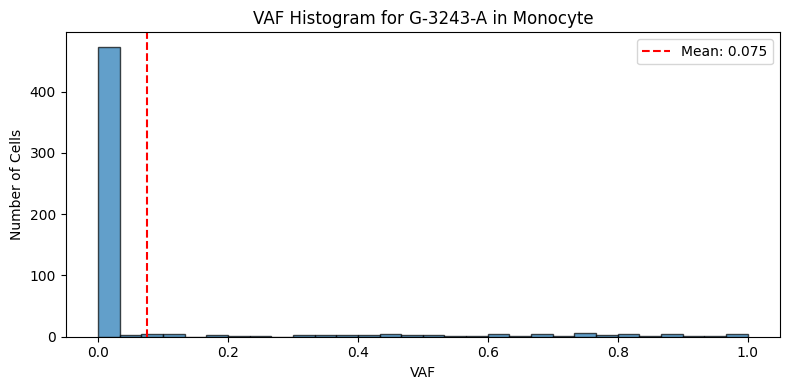

Cell type: Monocyte
  Mean VAF: 0.075
  Median VAF: 0.000
  Min VAF: 0.000
  Max VAF: 1.000
  Number of cells: 546


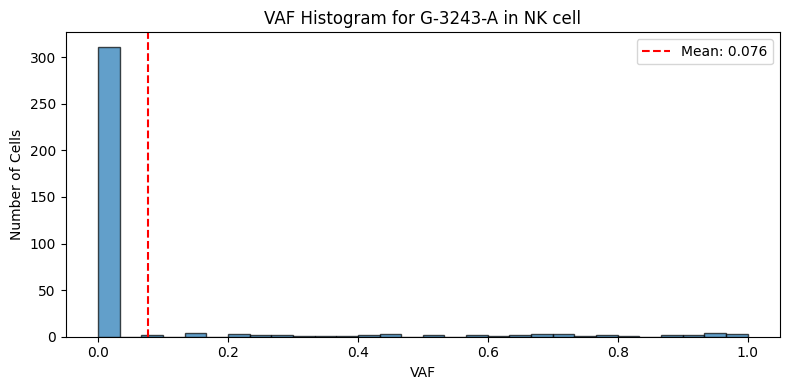

Cell type: NK cell
  Mean VAF: 0.076
  Median VAF: 0.000
  Min VAF: 0.000
  Max VAF: 1.000
  Number of cells: 360


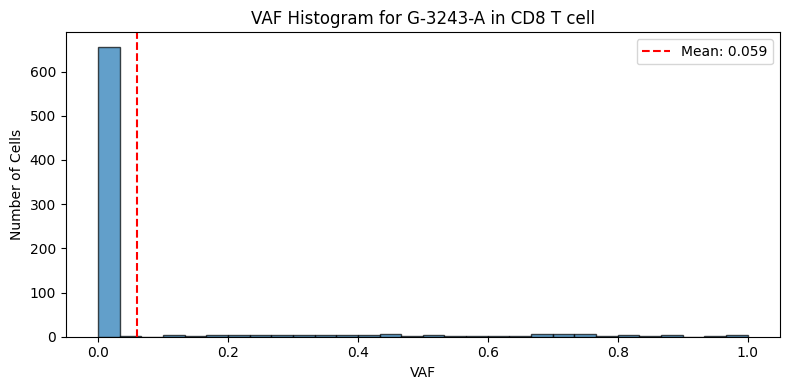

Cell type: CD8 T cell
  Mean VAF: 0.059
  Median VAF: 0.000
  Min VAF: 0.000
  Max VAF: 1.000
  Number of cells: 741


In [37]:
variant_name = "G-3243-A"
variant_names = mgatk.uns['variant_names']
vaf_values = mgatk.obsm['variant_vaf_high_quality'][:, variant_idx]
cell_types = WBC048.obs['cell_type_manual'].unique()

def test_vaf_histogram_per_cell_type():
    for cell_type in cell_types:
        mask = WBC048.obs['cell_type_manual'] == cell_type
        vaf_for_type = vaf_values[mask]
        plt.figure(figsize=(8, 4))
        plt.hist(vaf_for_type, bins=30, alpha=0.7, edgecolor='black')
        plt.title(f'VAF Histogram for {variant_name} in {cell_type}')
        plt.xlabel('VAF')
        plt.ylabel('Number of Cells')
        plt.axvline(np.mean(vaf_for_type), color='red', linestyle='--', label=f'Mean: {np.mean(vaf_for_type):.3f}')
        plt.legend()
        plt.tight_layout()
        plt.show()
        print(f"Cell type: {cell_type}")
        print(f"  Mean VAF: {np.mean(vaf_for_type):.3f}")
        print(f"  Median VAF: {np.median(vaf_for_type):.3f}")
        print(f"  Min VAF: {np.min(vaf_for_type):.3f}")
        print(f"  Max VAF: {np.max(vaf_for_type):.3f}")
        print(f"  Number of cells: {len(vaf_for_type)}")
test_vaf_histogram_per_cell_type()

In [38]:
##Differential accessibility between cell types with and without the 3243 variant
import polars as pl

snap.tl.macs3(WBC048, groupby='cell_type_manual')
peaks = snap.tl.merge_peaks(WBC048.uns['macs3'], snap.genome.hg38)
peaks.head()

2025-11-24 14:19:58 - INFO - Exporting fragments...
2025-11-24 14:20:02 - INFO - Calling peaks...
100%|██████████| 5/5 [01:09<00:00, 13.83s/it]


Peaks,CD4 T cell,Monocyte,NK cell,B cell,CD8 T cell
str,bool,bool,bool,bool,bool
"""chr1:9843-10344""",true,true,true,true,true
"""chr1:191603-192104""",true,true,false,false,true
"""chr1:267755-268256""",true,true,false,true,true
"""chr1:271056-271557""",false,true,false,false,false
"""chr1:275020-275521""",false,true,false,false,false


In [39]:
peak_mat = snap.pp.make_peak_matrix(WBC048, use_rep=peaks['Peaks'])
peak_mat


AnnData object with n_obs × n_vars = 3801 × 149225
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden', 'cell_type_manual'

2025-11-24 14:21:13 - WARNING - Input contains 66125 peaks, only 50000 peaks will be plotted.


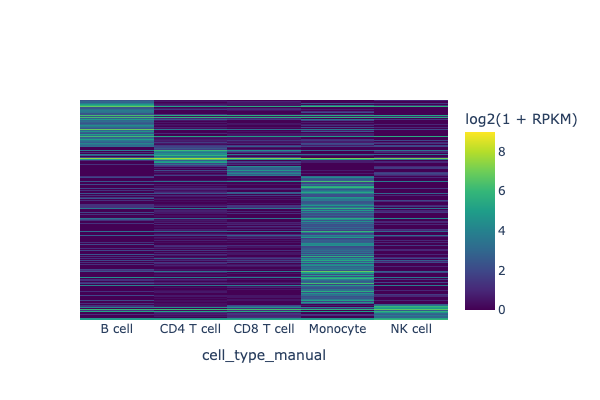

In [40]:
marker_peaks = snap.tl.marker_regions(peak_mat, groupby='cell_type_manual', pvalue=0.05)
snap.pl.regions(peak_mat, groupby='cell_type_manual', peaks=marker_peaks, interactive=False)

In [41]:
import numpy as np
print(np.__version__)
motifs = snap.tl.motif_enrichment(
    motifs=snap.datasets.cis_bp(unique=True),
    regions=marker_peaks,
    genome_fasta=snap.genome.hg38,
)

2025-11-24 14:21:15 - INFO - Fetching 66125 sequences ...


1.26.4


2025-11-24 14:21:20 - INFO - Computing enrichment ...
100%|██████████| 1165/1165 [03:17<00:00,  5.91it/s]


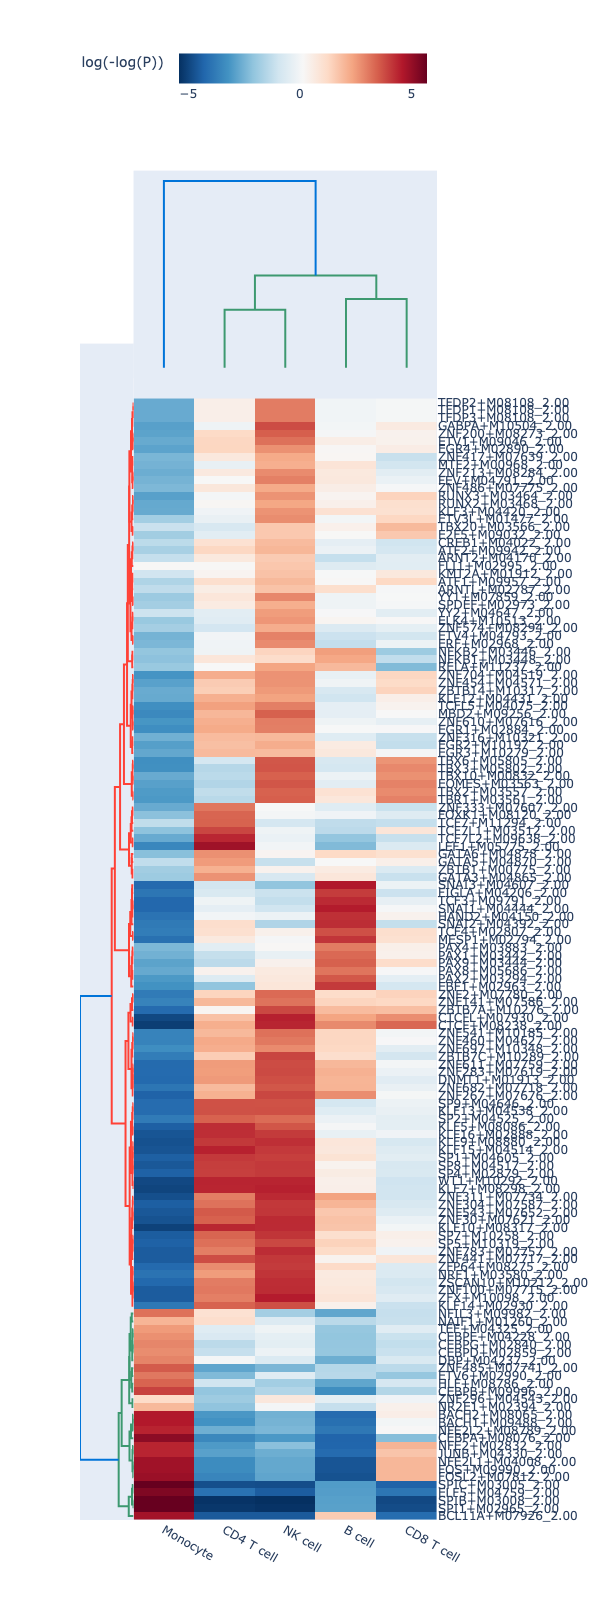

In [42]:
snap.pl.motif_enrichment(motifs, max_fdr=0.0001, height=1600, interactive=False)

In [43]:
## CD8 DIFF TEST 
variant_name = "G-3243-A"
variant_names = mgatk.uns['variant_names']
print(len(variant_names))
variant_idx = variant_names.index(variant_name)
vaf_values = mgatk.obsm['variant_vaf_high_quality'][:, variant_idx]

WBC048.obs['vaf_3243'] = vaf_values

# Create new group labels for CD8 T cell 3243+ and 3243-
WBC048.obs['cd8_3243_status'] = 'Other'
WBC048.obs.loc[
    (WBC048.obs['cell_type_manual'] == 'CD8 T cell') & (WBC048.obs['vaf_3243'] > 0.1),
    'cd8_3243_status'
] = 'CD8 T cell 3243+'
WBC048.obs.loc[
    (WBC048.obs['cell_type_manual'] == 'CD8 T cell') & (WBC048.obs['vaf_3243'] == 0),
    'cd8_3243_status'
] = 'CD8 T cell 3243-'

# Now you can use these groups for downstream analysis
print(WBC048.obs['cd8_3243_status'].value_counts())

group1 = "CD8 T cell 3243+"
group2 = "CD8 T cell 3243-"
pos_3243 = WBC048.obs['cd8_3243_status'] == group1
neg_3243 = WBC048.obs['cd8_3243_status'] == group2
peaks_selected = np.ones(peak_mat.shape[1], dtype=bool)


print("Number of matches (True):", pos_3243.sum())
print("Number of non-matches (False):", (~pos_3243).sum())
print("Value counts:\n", pd.Series(pos_3243).value_counts())
print("Number of matches (True):", neg_3243.sum())
print("Number of non-matches (False):", (~neg_3243).sum())
print("Value counts:\n", pd.Series(neg_3243).value_counts())
print("Overlap:", np.sum(pos_3243 & neg_3243))  # Should be 0

6630
cd8_3243_status
Other               3062
CD8 T cell 3243-     656
CD8 T cell 3243+      83
Name: count, dtype: int64
Number of matches (True): 83
Number of non-matches (False): 3718
Value counts:
 cd8_3243_status
False    3718
True       83
Name: count, dtype: int64
Number of matches (True): 656
Number of non-matches (False): 3145
Value counts:
 cd8_3243_status
False    3145
True      656
Name: count, dtype: int64
Overlap: 0


In [44]:
diff_peaks = snap.tl.diff_test(
    peak_mat,
    cell_group1=pos_3243,
    cell_group2=neg_3243,
    features=peaks_selected,
    min_log_fc = 0.25,
    min_pct=0.2,
)

2025-11-24 14:24:39 - INFO - Input contains 149225 features, now perform filtering with 'min_log_fc = 0.25' and 'min_pct = 0.2' ...
2025-11-24 14:24:42 - INFO - Testing 4161 features ...
100%|██████████| 4161/4161 [00:11<00:00, 375.55it/s]


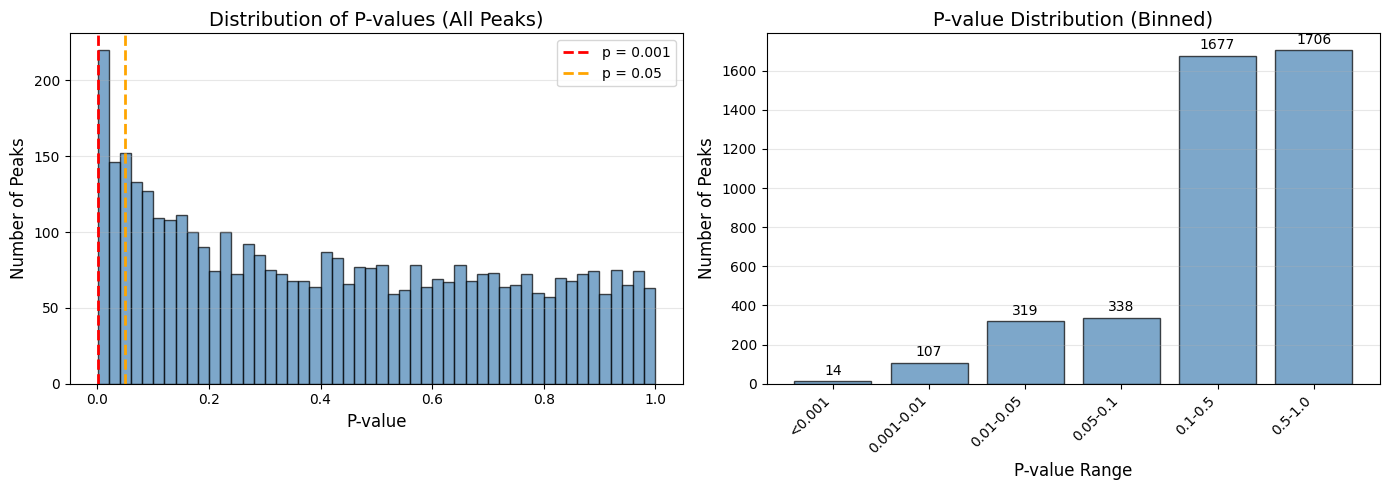


=== P-VALUE DISTRIBUTION SUMMARY ===
Total peaks tested: 4161
Peaks with p < 0.001: 14 (0.3%)
Peaks with p < 0.01: 121 (2.9%)
Peaks with p < 0.05: 440 (10.6%)
Minimum p-value: 1.40e-04
Maximum p-value: 1.00e+00
Median p-value: 0.4042

=== COUNTS BY P-VALUE RANGE ===
<0.001: 14
0.001-0.01: 107
0.01-0.05: 319
0.05-0.1: 338
0.1-0.5: 1677
0.5-1.0: 1706


In [45]:
# Python
# filepath: /Users/lucascortes/Documents/Pickett/mtscATAC-Seq/2025_049_Sarah_Pickett/WBC048_outs/WBC_analysis.ipynb

import matplotlib.pyplot as plt
import numpy as np

# Convert to pandas to access p-values
diff_peaks_df = diff_peaks.to_pandas()

# Get p-values
p_values = diff_peaks_df['p-value']

# Create histogram/bar chart of p-value distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with many bins for detailed distribution
ax1.hist(p_values, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('P-value', fontsize=12)
ax1.set_ylabel('Number of Peaks', fontsize=12)
ax1.set_title('Distribution of P-values (All Peaks)', fontsize=14)
ax1.axvline(x=0.001, color='red', linestyle='--', linewidth=2, label='p = 0.001')
ax1.axvline(x=0.05, color='orange', linestyle='--', linewidth=2, label='p = 0.05')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Bar chart with binned p-values
p_value_bins = [0, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
bin_labels = ['<0.001', '0.001-0.01', '0.01-0.05', '0.05-0.1', '0.1-0.5', '0.5-1.0']
counts, _ = np.histogram(p_values, bins=p_value_bins)

bars = ax2.bar(range(len(counts)), counts, alpha=0.7, color='steelblue', edgecolor='black')
ax2.set_xticks(range(len(counts)))
ax2.set_xticklabels(bin_labels, rotation=45, ha='right')
ax2.set_xlabel('P-value Range', fontsize=12)
ax2.set_ylabel('Number of Peaks', fontsize=12)
ax2.set_title('P-value Distribution (Binned)', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Add counts on top of bars
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01, 
             str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n=== P-VALUE DISTRIBUTION SUMMARY ===")
print(f"Total peaks tested: {len(p_values)}")
print(f"Peaks with p < 0.001: {(p_values < 0.001).sum()} ({(p_values < 0.001).sum()/len(p_values)*100:.1f}%)")
print(f"Peaks with p < 0.01: {(p_values < 0.01).sum()} ({(p_values < 0.01).sum()/len(p_values)*100:.1f}%)")
print(f"Peaks with p < 0.05: {(p_values < 0.05).sum()} ({(p_values < 0.05).sum()/len(p_values)*100:.1f}%)")
print(f"Minimum p-value: {p_values.min():.2e}")
print(f"Maximum p-value: {p_values.max():.2e}")
print(f"Median p-value: {p_values.median():.4f}")

print(f"\n=== COUNTS BY P-VALUE RANGE ===")
for label, count in zip(bin_labels, counts):
    print(f"{label}: {count}")


=== CELL-LEVEL FILTERING SUMMARY ===
Total cells: 3801
Cells with at least one variant detected: 3479
Cells with NO variants detected (all zeros): 322
Percentage of cells retained: 91.5%

=== VARIANTS PER CELL DISTRIBUTION ===
Mean variants per cell: 6.43
Median variants per cell: 7.00
Max variants in a cell: 12
Min variants in a cell: 0


Text(0.5, 1.0, 'Distribution of Variant Counts per Cell (After Filtering)')

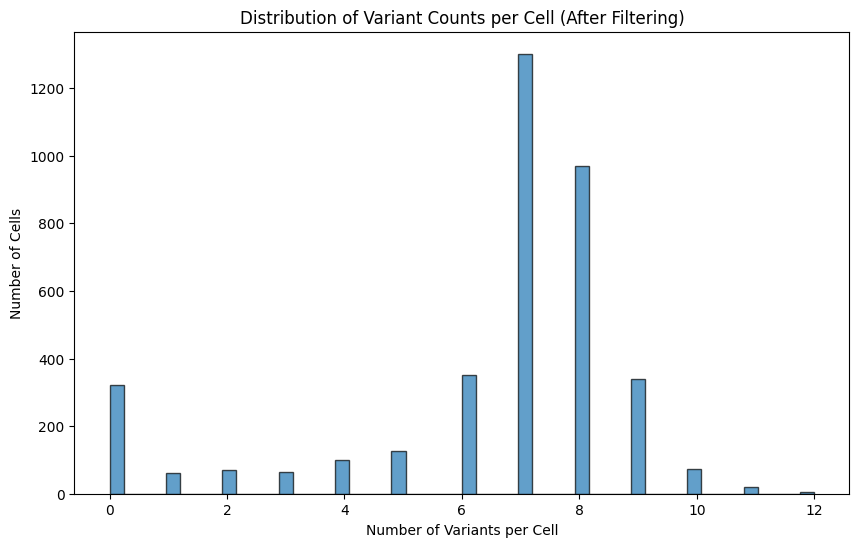

In [46]:
# Python
# filepath: /Users/lucascortes/Documents/Pickett/mtscATAC-Seq/2025_049_Sarah_Pickett/WBC048_outs/WBC_analysis.ipynb

# Count cells with all-zero VAF values after filtering
cells_with_any_variant = (high_quality_vaf_matrix > 0).any(axis=1).sum()
cells_with_no_variants = len(high_quality_vaf_matrix) - cells_with_any_variant

print(f"\n=== CELL-LEVEL FILTERING SUMMARY ===")
print(f"Total cells: {len(high_quality_vaf_matrix)}")
print(f"Cells with at least one variant detected: {cells_with_any_variant}")
print(f"Cells with NO variants detected (all zeros): {cells_with_no_variants}")
print(f"Percentage of cells retained: {cells_with_any_variant / len(high_quality_vaf_matrix) * 100:.1f}%")

# Also show distribution of number of variants per cell
variants_per_cell = (high_quality_vaf_matrix > 0).sum(axis=1)
print(f"\n=== VARIANTS PER CELL DISTRIBUTION ===")
print(f"Mean variants per cell: {variants_per_cell.mean():.2f}")
print(f"Median variants per cell: {np.median(variants_per_cell):.2f}")
print(f"Max variants in a cell: {variants_per_cell.max()}")
print(f"Min variants in a cell: {variants_per_cell.min()}")

# Optional: Plot histogram
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(variants_per_cell, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Number of Variants per Cell')
plt.ylabel('Number of Cells')
plt.title('Distribution of Variant Counts per Cell (After Filtering)')


In [48]:
## Differential gene expresssion for all cell types between 3243+ and 3243-
variant_name = "G-3243-A"
variant_names = mgatk.uns['variant_names']
variant_idx = mgatk.uns['variant_names'].index(variant_name)
vaf_values = mgatk.obsm['variant_vaf_high_quality'][:, variant_idx]

WBC048.obs['vaf_3243'] = vaf_values

# Create new group labels for CD8 T cell 3243+ and 3243-
WBC048.obs['3243_status'] = 'Other'
WBC048.obs.loc[
    WBC048.obs['vaf_3243'] > 0.1,
    '3243_status'
] = 'cell 3243+'
WBC048.obs.loc[
    WBC048.obs['vaf_3243'] == 0,
    '3243_status'
] = 'cell 3243-'

# Now you can use these groups for downstream analysis
print(WBC048.obs['3243_status'].value_counts())

group1 = "cell 3243+"
group2 = "cell 3243-"
pos_3243 = WBC048.obs['3243_status'] == group1
neg_3243 = WBC048.obs['3243_status'] == group2
peaks_selected = np.ones(peak_mat.shape[1], dtype=bool)


print("Number of matches (True):", pos_3243.sum())
print("Number of non-matches (False):", (~pos_3243).sum())
print("Value counts:\n", pd.Series(pos_3243).value_counts())
print("Number of matches (True):", neg_3243.sum())
print("Number of non-matches (False):", (~neg_3243).sum())
print("Value counts:\n", pd.Series(neg_3243).value_counts())
print("Overlap:", np.sum(pos_3243 & neg_3243))  # Should be 0

3243_status
cell 3243-    3295
cell 3243+     478
Other           28
Name: count, dtype: int64
Number of matches (True): 478
Number of non-matches (False): 3323
Value counts:
 3243_status
False    3323
True      478
Name: count, dtype: int64
Number of matches (True): 3295
Number of non-matches (False): 506
Value counts:
 3243_status
True     3295
False     506
Name: count, dtype: int64
Overlap: 0


In [49]:
diff_peaks = snap.tl.diff_test(
    peak_mat,
    cell_group1=pos_3243,
    cell_group2=neg_3243,
    features=peaks_selected,
    min_log_fc = 0.25,
    min_pct=0.2,
)


2025-11-24 14:27:22 - INFO - Input contains 149225 features, now perform filtering with 'min_log_fc = 0.25' and 'min_pct = 0.2' ...
2025-11-24 14:27:26 - INFO - Testing 483 features ...
100%|██████████| 483/483 [00:02<00:00, 218.26it/s]


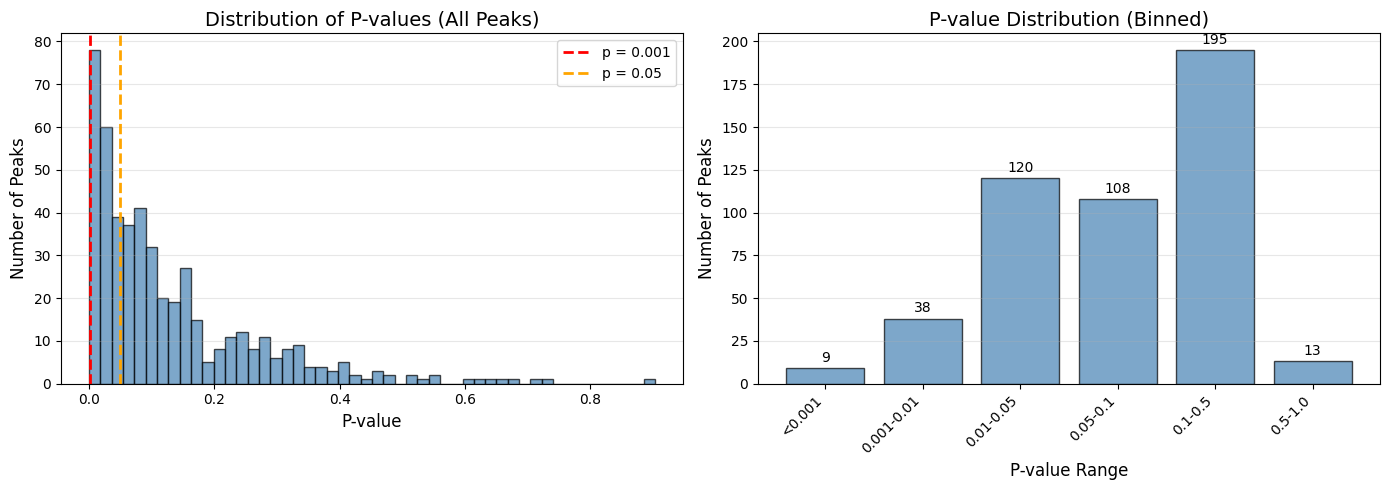


=== P-VALUE DISTRIBUTION SUMMARY ===
Total peaks tested: 483
Peaks with p < 0.001: 9 (1.9%)
Peaks with p < 0.01: 47 (9.7%)
Peaks with p < 0.05: 167 (34.6%)
Minimum p-value: 1.00e-04
Maximum p-value: 9.03e-01
Median p-value: 0.0829

=== COUNTS BY P-VALUE RANGE ===
<0.001: 9
0.001-0.01: 38
0.01-0.05: 120
0.05-0.1: 108
0.1-0.5: 195
0.5-1.0: 13


In [50]:
# Python
# filepath: /Users/lucascortes/Documents/Pickett/mtscATAC-Seq/2025_049_Sarah_Pickett/WBC048_outs/WBC_analysis.ipynb

import matplotlib.pyplot as plt
import numpy as np

# Convert to pandas to access p-values
diff_peaks_df = diff_peaks.to_pandas()

# Get p-values
p_values = diff_peaks_df['p-value']

# Create histogram/bar chart of p-value distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with many bins for detailed distribution
ax1.hist(p_values, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('P-value', fontsize=12)
ax1.set_ylabel('Number of Peaks', fontsize=12)
ax1.set_title('Distribution of P-values (All Peaks)', fontsize=14)
ax1.axvline(x=0.001, color='red', linestyle='--', linewidth=2, label='p = 0.001')
ax1.axvline(x=0.05, color='orange', linestyle='--', linewidth=2, label='p = 0.05')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Bar chart with binned p-values
p_value_bins = [0, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
bin_labels = ['<0.001', '0.001-0.01', '0.01-0.05', '0.05-0.1', '0.1-0.5', '0.5-1.0']
counts, _ = np.histogram(p_values, bins=p_value_bins)

bars = ax2.bar(range(len(counts)), counts, alpha=0.7, color='steelblue', edgecolor='black')
ax2.set_xticks(range(len(counts)))
ax2.set_xticklabels(bin_labels, rotation=45, ha='right')
ax2.set_xlabel('P-value Range', fontsize=12)
ax2.set_ylabel('Number of Peaks', fontsize=12)
ax2.set_title('P-value Distribution (Binned)', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Add counts on top of bars
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01, 
             str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n=== P-VALUE DISTRIBUTION SUMMARY ===")
print(f"Total peaks tested: {len(p_values)}")
print(f"Peaks with p < 0.001: {(p_values < 0.001).sum()} ({(p_values < 0.001).sum()/len(p_values)*100:.1f}%)")
print(f"Peaks with p < 0.01: {(p_values < 0.01).sum()} ({(p_values < 0.01).sum()/len(p_values)*100:.1f}%)")
print(f"Peaks with p < 0.05: {(p_values < 0.05).sum()} ({(p_values < 0.05).sum()/len(p_values)*100:.1f}%)")
print(f"Minimum p-value: {p_values.min():.2e}")
print(f"Maximum p-value: {p_values.max():.2e}")
print(f"Median p-value: {p_values.median():.4f}")

print(f"\n=== COUNTS BY P-VALUE RANGE ===")
for label, count in zip(bin_labels, counts):
    print(f"{label}: {count}")

In [51]:
import pandas as pd
import gzip


annotation_path = snap.genome.hg38.annotation

gene_records = []
with gzip.open(annotation_path, 'rt') as f:
    for line in f:
        if line.startswith('#'):
            continue
        parts = line.strip().split('\t')
        if len(parts) < 9:
            continue
        if parts[2] == 'gene':
            chrom = parts[0]
            start = int(parts[3])
            end = int(parts[4])
            strand = parts[6]
            attrs = dict(item.split('=') for item in parts[8].split(';') if '=' in item)
            gene_name = attrs.get('gene_name', '')
            gene_records.append({
                'chrom': chrom,
                'start': start,
                'end': end,
                'strand': strand,
                'gene_name': gene_name
            })

# Create DataFrame once
gene_anno = pd.DataFrame(gene_records)
print(f"Loaded {len(gene_anno)} genes")

# ✅ NOW the function just looks up in the pre-loaded DataFrame
def region_to_gene(region):
    chrom, coords = region.split(":")
    peak_start, peak_end = map(int, coords.split("-"))
    peak_center = (peak_start + peak_end) // 2
    
    overlapping = gene_anno[
        (gene_anno["chrom"] == chrom) &
        (gene_anno["end"] >= peak_start) &
        (gene_anno["start"] <= peak_end)
    ]
    
    if not overlapping.empty:
        gene_info = []
        for _, gene in overlapping.iterrows():
            if gene['strand'] == '+':
                tss = gene['start']
            elif gene['strand'] == '-':
                tss = gene['end']
            else:
                tss = gene['start']
            
            dist_to_tss = peak_center - tss
            gene_info.append(f"{gene['gene_name']},TSS{dist_to_tss})")
        
        return ";".join(gene_info)
    else:
        return "intergenic"

# Now annotate - should be 1000x faster
df_peaks["gene_annotation"] = df_peaks["feature name"].apply(region_to_gene)



Loaded 61852 genes


NameError: name 'df_peaks' is not defined

In [52]:
# Extract just the first gene name (before comma) for cleaner labels
def get_first_gene(annotation):
    if annotation == "intergenic":
        return "intergenic"
    # Get first gene name before comma
    first_gene = annotation.split(";")[0].split(",")[0]
    return first_gene if first_gene else "intergenic"

In [53]:
from dash import Dash, dcc, html, Input, Output, callback
import dash_bio as dashbio
import plotly as pio
def produce_volcano_plot(df_peaks, filename, cell_type):
    df_peaks["gene_label"] = df_peaks["gene_annotation"].apply(get_first_gene)

    # Calculate -log10(p-value) for volcano plot
    df_peaks['neg_log10_pval'] = -np.log10(df_peaks['p-value'])

    # Create volcano plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # highlight down- or up- regulated genes
    down = (df_peaks['log2(fold_change)']<=-0.25)&(df_peaks['p-value']<=0.001)
    up = (df_peaks['log2(fold_change)']>=0.25)&(df_peaks['p-value']<=0.001)
    colors = ['red' if up else 'blue' if down else 'gray' 
              for up, down in zip(up, down)]

    # Scatter plot
    ax.scatter(
        df_peaks['log2(fold_change)'], 
        df_peaks['neg_log10_pval'],
        c=colors,
        alpha=0.6,
        s=20
    )

    # Add threshold lines
    ax.axhline(y=-np.log10(0.001), color='blue', linestyle='--', linewidth=1, label='p-value = 0.001')
    ax.axvline(x=0.25, color='blue', linestyle='--', linewidth=1, label='log2FC = 0.25')
    ax.axvline(x=-0.25, color='blue', linestyle='--', linewidth=1)

    


    # Get top 20 significant peaks
    peaks_to_label = df_peaks[
        (df_peaks['gene_label'] != 'intergenic') &
        (df_peaks['p-value'] < 0.001) & 
        (np.abs(df_peaks['log2(fold_change)']) > 0.25)
    ].nsmallest(50, 'p-value')

    # Label the peaks
    for idx, row in peaks_to_label.iterrows():
        ax.annotate(
            row['gene_label'],
            xy=(row['log2(fold_change)'], row['neg_log10_pval']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            alpha=0.8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.3, edgecolor='blue')
        )

    # Labels and title
    ax.set_xlabel('log2(Fold Change)', fontsize=12)
    ax.set_ylabel('-log10(p-value)', fontsize=12)
    ax.set_title(f'Volcano Plot: Differential Accessibility ({cell_type})', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add text summary
    n_sig_up = ((df_peaks['p-value'] < 0.001) & (df_peaks['log2(fold_change)'] > 0.25)).sum()
    n_sig_down = ((df_peaks['p-value'] < 0.001) & (df_peaks['log2(fold_change)'] < -0.25)).sum()
    ax.text(0.05, 0.95, f'Significant peaks:\nUp: {n_sig_up}\nDown: {n_sig_down}', 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    volcanoplot = dashbio.VolcanoPlot(
    dataframe=df_peaks,
    effect_size='log2(fold_change)',
    p='p-value',
    snp = 'gene_annotation',
    gene = 'gene_label',
    effect_size_line = [-0.25, 0.25],
    genomewideline_value = -np.log10(0.001),
    effect_size_line_color="#7F22E3",
    genomewideline_color='#EF553B',
    highlight_color="#F30C0C",
    col="#404142"   
)
        # Option 1: Save as interactive HTML (recommended)
    volcanoplot.write_html(f"volcano_plot_interactive_{cell_type}.html")

    # Option 2: Save as static image (requires kaleido)
    volcanoplot.write_image(f"volcano_plot_{cell_type}.png", width=1200, height=800)
    


In [54]:
def go_enrichment_plot(gene_list, filename):
    import gseapy as gp
    import matplotlib.pyplot as plt
    from gseapy import barplot
    
    try:
        # if you are only interested in dataframe that enrichr returned, please set outdir=None
        enr = gp.enrichr(
            gene_list=gene_list,
            gene_sets=['MSigDB_Hallmark_2020','KEGG_2021_Human'],
            organism='human',
            outdir=None,
        )
        
        # categorical scatterplot
        ax = barplot(
            enr.results,
            column="Adjusted P-value",
            group='Gene_set',
            size=10,
            top_term=5,
            figsize=(3,5),
            color={'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'},
            cutoff=1
        )
        plt.tight_layout()
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ GO enrichment plot saved: {filename}")
        
    except Exception as e:
        print(f"⚠️ Warning: GO enrichment failed for {filename}")
        print(f"   Error: {e}")
        print(f"   Skipping GO enrichment for this cell type.")

In [57]:
def differential_expression_by_cell_type(WBC048, mgatk, peak_mat, variant_name, upper_VAF=0.1, lower_VAF=0.0):
    variant_names = mgatk.uns['variant_names']
    variant_idx = mgatk.uns['variant_names'].index(variant_name)
    vaf_values = mgatk.obsm['variant_vaf_high_quality'][:, variant_idx]

    WBC048.obs['vaf'+ variant_name] = vaf_values

    cell_types = WBC048.obs['cell_type_manual'].unique().tolist()

    for cell in range(len(cell_types)):
        cell_status = cell_types[cell] +'_3243_status'
        positive_cells = cell_types[cell] + variant_name + '+'
        negative_cells = cell_types[cell] + variant_name + '-'
        WBC048.obs[cell_status] = 'Other'
        WBC048.obs.loc[
            (WBC048.obs['cell_type_manual'] == cell_types[cell]) & (WBC048.obs['vaf_3243'] >= upper_VAF),
            cell_status
        ] = positive_cells
        WBC048.obs.loc[
            (WBC048.obs['cell_type_manual'] == cell_types[cell]) & (WBC048.obs['vaf_3243'] <= lower_VAF),
            cell_status
        ] = negative_cells
        # Now you can use these groups for downstream analysis
        group1 = positive_cells
        group2 = negative_cells
        pos_variant = WBC048.obs[cell_status] == group1
        neg_variant = WBC048.obs[cell_status] == group2
        peaks_selected = np.ones(peak_mat.shape[1], dtype=bool)
        print("Number of matches (True):", pos_variant.sum())
        print("Number of non-matches (False):", (~pos_variant).sum())
        print("Value counts:\n", pd.Series(pos_variant).value_counts())
        print("Number of matches (True):", neg_variant.sum())
        print("Number of non-matches (False):", (~neg_variant).sum())
        print("Value counts:\n", pd.Series(neg_variant).value_counts())
        print("Overlap:", np.sum(pos_variant & neg_variant))  # Should be 0
        try:
            diff_peaks = snap.tl.diff_test(
                peak_mat,
                cell_group1=pos_variant,
                cell_group2=neg_variant,
                min_log_fc = 0.25,
                min_pct=0.01,
            )
            diff_peaks_filtered = diff_peaks.filter(pl.col('p-value') < 0.001)
            #df = diff_peaks.to_pandas()
            df_filtered = diff_peaks_filtered.to_pandas()
            df_filtered["gene_annotation"] = df_filtered["feature name"].apply(region_to_gene)
            # Extract unique gene names from the annotations
            gene_list = []
            for annotation in df_filtered["gene_annotation"]:
                if annotation != "intergenic":
                    # Split by semicolon (multiple genes) and extract gene names
                    for gene_entry in annotation.split(";"):
                        gene_name = gene_entry.split(",")[0]  # Get gene name before comma
                        if gene_name:
                            gene_list.append(gene_name)

            # Get unique genes
            unique_genes = list(set(gene_list))
            print(f"Total unique genes: {len(unique_genes)}")
            print("Gene list:", unique_genes)

            # Save to file for GO analysis
            with open(f"differential_peaks_genes_{cell_types[cell]}_{variant_name}.txt", "w") as f:
                for gene in unique_genes:
                    f.write(f"{gene}\n")

            print(f"\nGene list saved to 'differential_peaks_genes_{cell_types[cell]}_{variant_name}.txt'")
            df_peaks = diff_peaks.to_pandas()
            df_peaks["gene_annotation"] = df_peaks["feature name"].apply(region_to_gene)
            print("Finished annotating genes for ", cell_types[cell])
            df_peaks["gene_label"] = df_peaks["gene_annotation"].apply(get_first_gene)

            # Calculate -log10(p-value) for volcano plot
            df_peaks['neg_log10_pval'] = -np.log10(df_peaks['p-value'])

            produce_volcano_plot(df_peaks, f"volcano_plot_{cell_types[cell]}_{variant_name}.png", cell_status)
            print("Volcano plot saved for ", cell_types[cell])
            go_enrichment_plot(gene_list, f"go_enrichment_{cell_types[cell]}_{variant_name}.png")
        except Exception as e:
            print(f"⚠️ Warning: Differential expression failed for {cell_types[cell]}")
            print(f"   Error: {e}")
            print(f"   Skipping this cell type.")
        
    

                

2025-11-24 14:30:55 - INFO - Input contains 149225 features, now perform filtering with 'min_log_fc = 0.25' and 'min_pct = 0.01' ...


Number of matches (True): 241
Number of non-matches (False): 3560
Value counts:
 CD4 T cell_3243_status
False    3560
True      241
Name: count, dtype: int64
Number of matches (True): 1672
Number of non-matches (False): 2129
Value counts:
 CD4 T cell_3243_status
False    2129
True     1672
Name: count, dtype: int64
Overlap: 0


2025-11-24 14:30:59 - INFO - Testing 32499 features ...
100%|██████████| 32499/32499 [01:53<00:00, 287.41it/s]


Total unique genes: 65
Gene list: ['FBXO3', 'FAM9B', 'FCGR3A', 'CLIC1', 'ENSG00000285280', 'RNVU1-4', 'FBLN5', 'XYLT2', 'RBL1', 'CCDC124', 'ERN1', 'BCL2', 'NUS1', 'PTGER2', 'SLC2A1', 'BEST1', 'BIVM-ERCC5', 'ENSG00000275443', 'LINC02572', 'MAP3K1', 'UBE2J1', 'ENSG00000235189', 'CTDP1-DT', 'PDHX', 'ERGIC1', 'RETREG1', 'SRPRA', 'ENSG00000274828', 'TGDS', 'ENSG00000287709', 'ENSG00000289768', 'FOXRED1', 'ZNF295-AS1', 'FTH1', 'TENT5C', 'ERCC5', 'TOGARAM2', 'ZBTB21', 'OBSL1', 'RNF122', 'ZNF343', 'APIP', 'TAB2', 'SBF2', 'FNBP1L', 'KATNAL1', 'ENSG00000286980', 'ENSG00000289424', 'MAPK8IP3', 'LRRC20', 'TRPM5', 'XYLT1', 'ENSG00000249061', 'REL', 'TBC1D2', 'DRAIC', 'ENSG00000273112', 'GNAS', 'LINC00623', 'ACTR3B', 'NPIPB11', 'MDS2', 'HACD2', 'DEPDC5', 'ANKH']

Gene list saved to 'differential_peaks_genes_CD4 T cell_G-3243-A.txt'
Finished annotating genes for  CD4 T cell


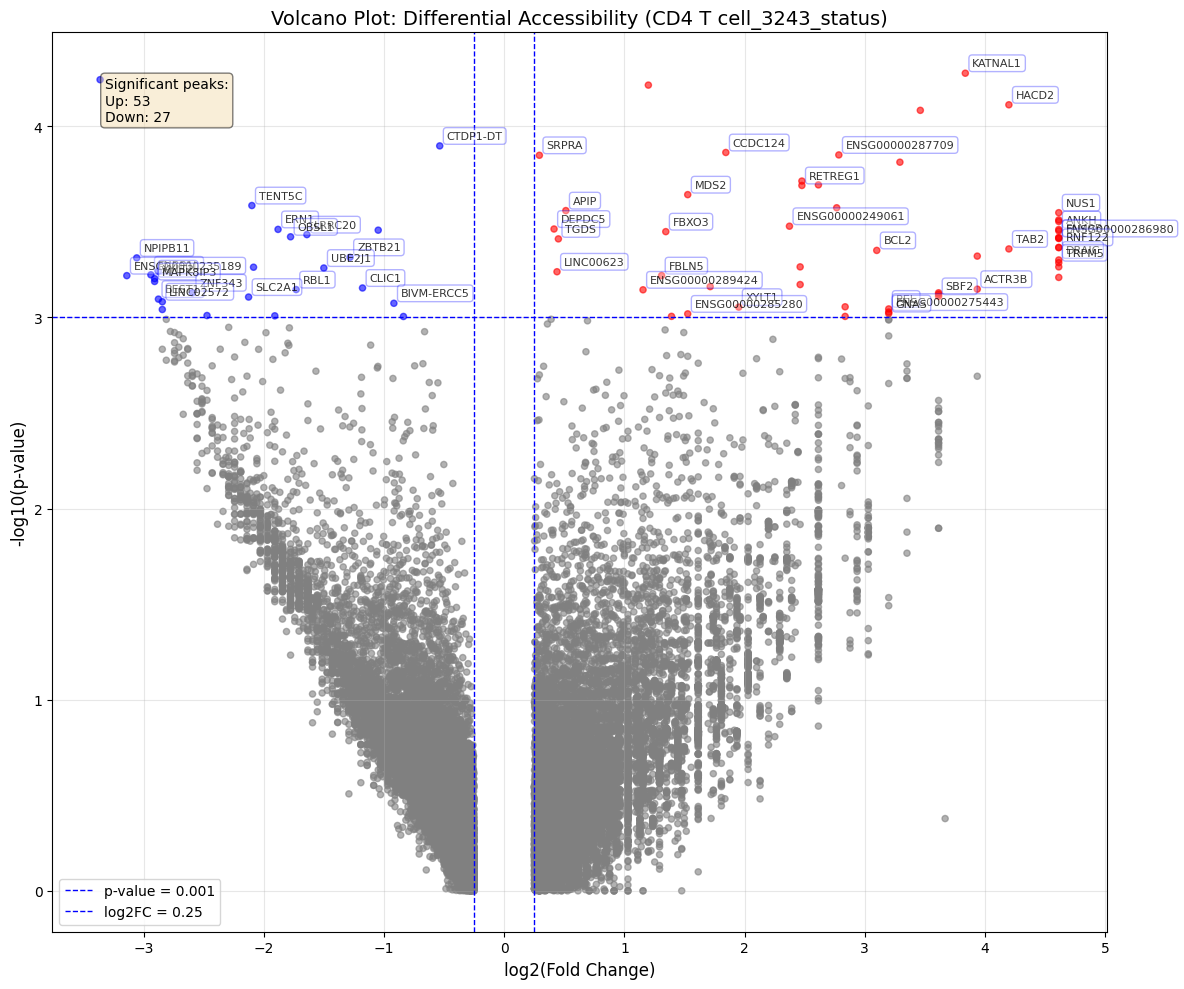

Volcano plot saved for  CD4 T cell


/Users/lucascortes/miniconda3/lib/python3.13/site-packages/gseapy/plot.py:753: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/folders/xk/48p4vmnj5z1g941ty5p14nbc0000gq/T/ipykernel_53812/1976349211.py:26: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



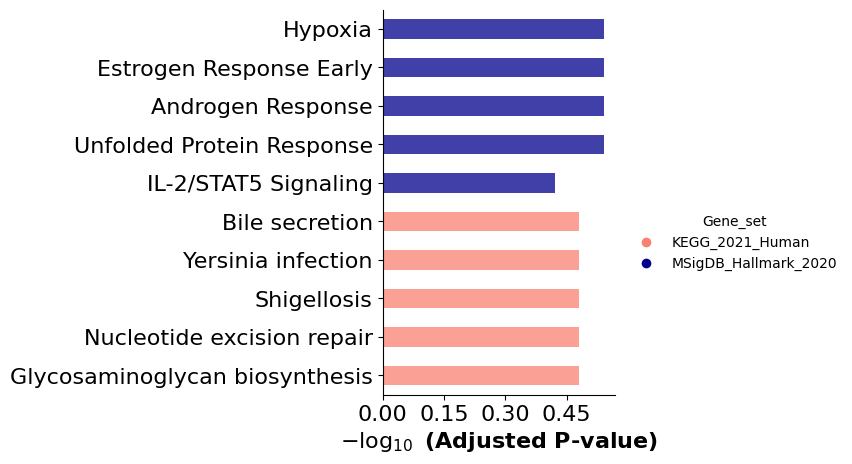

2025-11-24 14:33:42 - INFO - Input contains 149225 features, now perform filtering with 'min_log_fc = 0.25' and 'min_pct = 0.01' ...


✓ GO enrichment plot saved: go_enrichment_CD4 T cell_G-3243-A.png
Number of matches (True): 40
Number of non-matches (False): 3761
Value counts:
 B cell_3243_status
False    3761
True       40
Name: count, dtype: int64
Number of matches (True): 184
Number of non-matches (False): 3617
Value counts:
 B cell_3243_status
False    3617
True      184
Name: count, dtype: int64
Overlap: 0


2025-11-24 14:33:45 - INFO - Testing 68268 features ...


Epoch 164/1000:  16%|█▋        | 163/1000 [28:10<2:24:41, 10.37s/it, v_num=1, train_loss=1.74e+3]

100%|██████████| 68268/68268 [02:50<00:00, 400.27it/s]


Total unique genes: 52
Gene list: ['DAND5', 'OSBPL10', 'AMPD3', 'CAB39L', 'DGKE', 'COPS3', 'ENSG00000255968', 'NME2', 'SLC38A2-AS1', 'RADIL', 'TRIM25', 'CNMD', 'SCML4', 'ADAM7-AS1', 'TMEM9', 'PLCL1', 'SRRM3', 'PLEKHM1', 'PRSS56', 'COL6A4P1', 'CMTM7', 'SLC38A2', 'VAC14', 'TGFBRAP1', 'CLK4', 'ENSG00000241490', 'ATXN1', 'ENSG00000255240', 'ENSG00000250349', 'IER5', 'SLC38A4-AS1', 'NME1-NME2', 'ENSG00000249207', 'RNF145', 'GRIN2B', 'TENT5C', 'HEATR5B', 'ITPR2-AS1', 'RAD51B', 'FGF12', 'RXYLT1-AS1', 'DNM2', 'PRKACB', 'PPFIA2', 'SETDB2', 'GNG7', 'ENSG00000258162', 'CD63-AS1', 'RUNX2', 'FGF12-AS2', 'ST3GAL5', 'ZNF692']

Gene list saved to 'differential_peaks_genes_B cell_G-3243-A.txt'
Finished annotating genes for  B cell


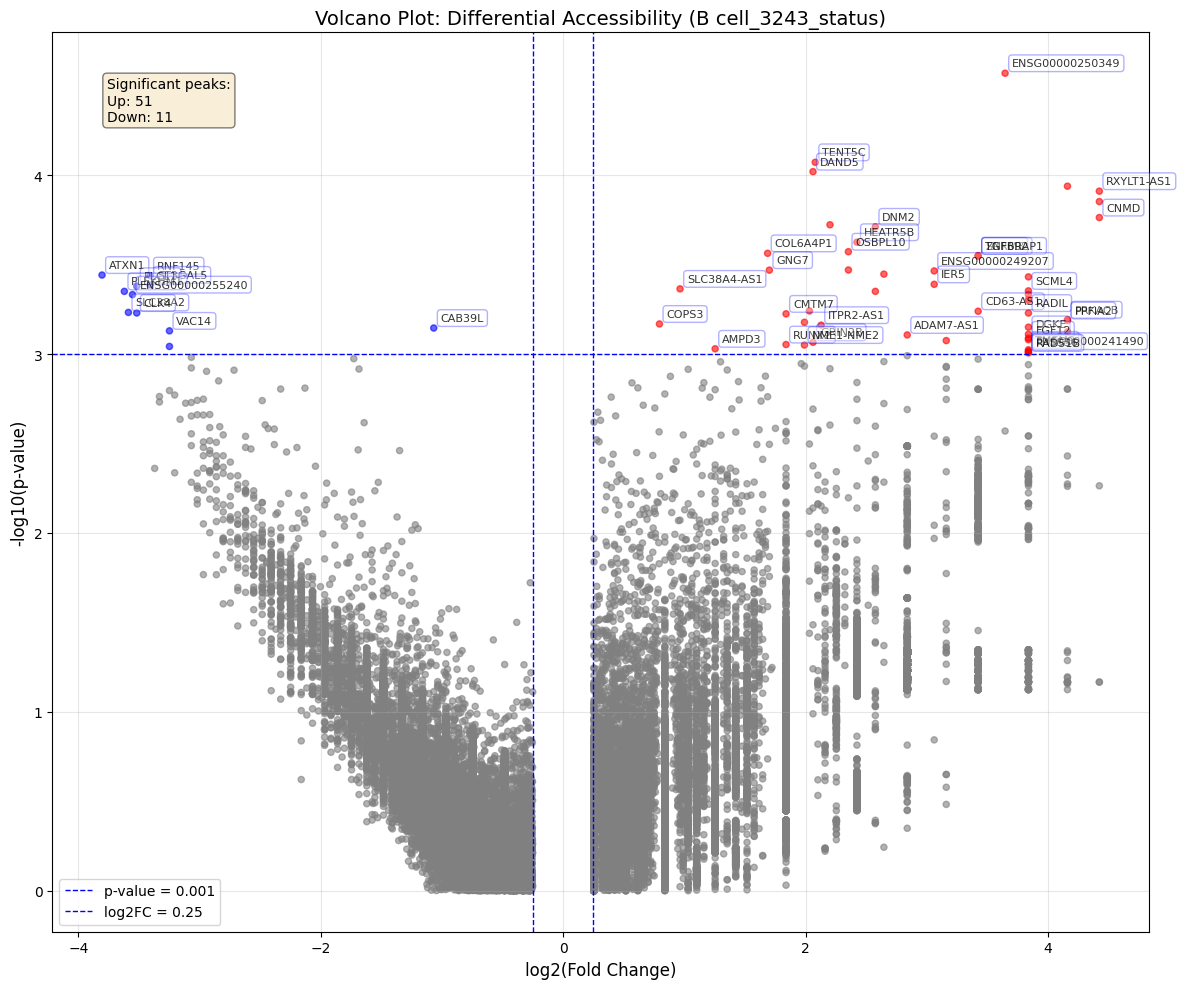

Volcano plot saved for  B cell


/Users/lucascortes/miniconda3/lib/python3.13/site-packages/gseapy/plot.py:753: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/folders/xk/48p4vmnj5z1g941ty5p14nbc0000gq/T/ipykernel_53812/1976349211.py:26: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



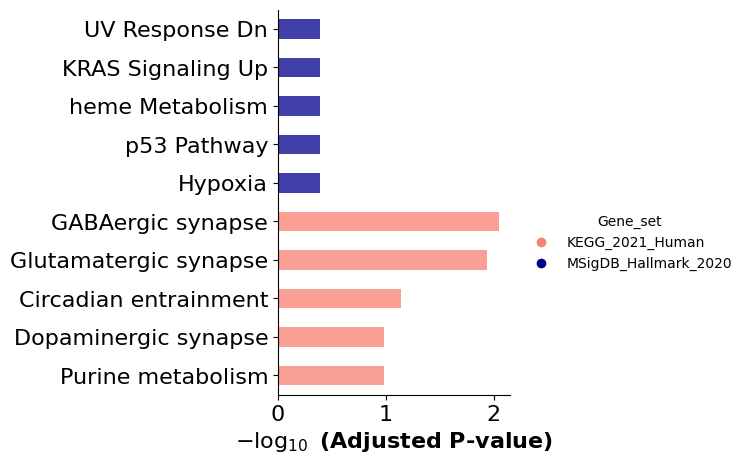

2025-11-24 14:38:13 - INFO - Input contains 149225 features, now perform filtering with 'min_log_fc = 0.25' and 'min_pct = 0.01' ...


✓ GO enrichment plot saved: go_enrichment_B cell_G-3243-A.png
Number of matches (True): 67
Number of non-matches (False): 3734
Value counts:
 Monocyte_3243_status
False    3734
True       67
Name: count, dtype: int64
Number of matches (True): 472
Number of non-matches (False): 3329
Value counts:
 Monocyte_3243_status
False    3329
True      472
Name: count, dtype: int64
Overlap: 0


2025-11-24 14:38:17 - INFO - Testing 78182 features ...
  0%|          | 7/78182 [00:00<04:22, 297.88it/s]
2025-11-24 14:38:17 - INFO - Input contains 149225 features, now perform filtering with 'min_log_fc = 0.25' and 'min_pct = 0.01' ...


⚠️ Warning: Differential expression failed for Monocyte
   Error: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1.0
   Skipping this cell type.
Number of matches (True): 47
Number of non-matches (False): 3754
Value counts:
 NK cell_3243_status
False    3754
True       47
Name: count, dtype: int64
Number of matches (True): 311
Number of non-matches (False): 3490
Value counts:
 NK cell_3243_status
False    3490
True      311
Name: count, dtype: int64
Overlap: 0


2025-11-24 14:38:20 - INFO - Testing 52817 features ...
100%|██████████| 52817/52817 [02:13<00:00, 396.37it/s]


Total unique genes: 111
Gene list: ['TNIP3', 'DENND2A', 'PGK1', 'RNU5E-4P', 'LINC00551', 'C1D', 'NUP88', 'PIK3R3', 'ENSG00000227240', 'P3R3URF-PIK3R3', 'PMP22', 'ARHGAP10', 'ANKRD22', 'ALK', 'AKAP13', 'ANKMY1', 'KIF13A', 'USP3-AS1', 'ARHGAP15', 'KCNAB1', 'MRTFA', 'NEMP2', 'ENSG00000287916', 'ZNF674', 'UBE2D2', 'LINC01344', 'ENSG00000265445', 'ENSG00000262633', 'VEZF1', 'TNFAIP8L2', 'MALT1', 'VIT', 'ENSG00000279660', 'LINC00578', 'KDM4C', 'ST8SIA4', 'ADAMTSL2', 'DENND1A', 'OSBPL8', 'TOX2', 'DUSP28', 'ENSG00000267476', 'SON', 'BLACAT1', 'ENSG00000273118', 'MGAM', 'ENSG00000289036', 'RAPGEF6', 'TP53I13', 'CLYBL', 'FBXO15', 'ENSG00000289912', 'DIAPH1', 'LUZP1', 'ENSG00000290082', 'RUNX1', 'LRRC2', 'ENSG00000273217', 'C4orf46P2', 'MYO5B', 'ENSG00000285646', 'RAPGEF1', 'TMTC1', 'AP1S3', 'ZNF674-AS1', 'LINC01675', 'SMPDL3A', 'DST', 'CARD11', 'LINC02507', 'ACSL3', 'FRMD4A', 'CCDC6', 'CDK6', 'GART', 'CHMP1A', 'SCNM1', 'CEP170B', 'LEMD1', 'ANXA1', 'BCL9', 'FBXL22', 'ENSG00000288932', 'MARCHF9', 

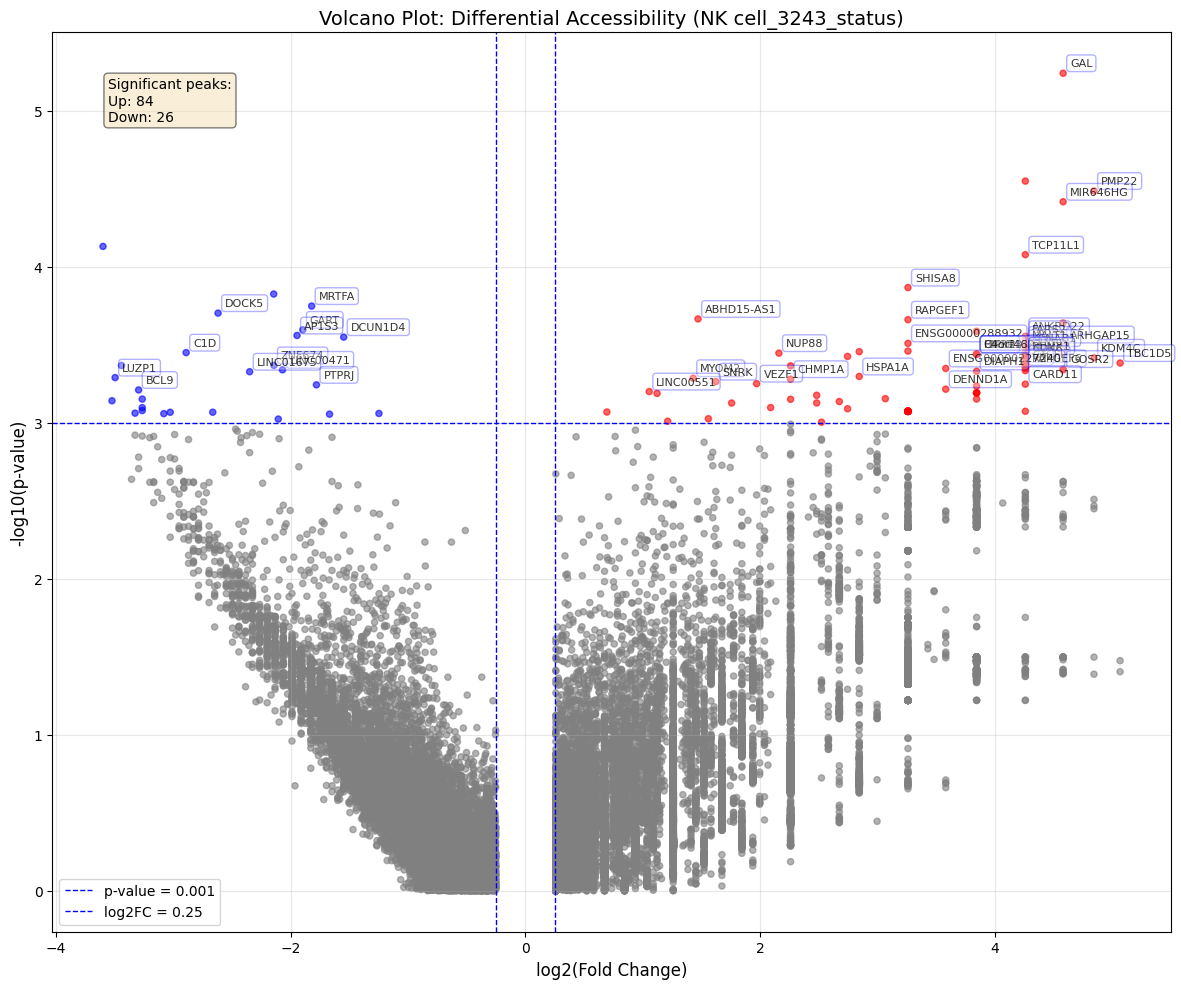

Volcano plot saved for  NK cell


/Users/lucascortes/miniconda3/lib/python3.13/site-packages/gseapy/plot.py:753: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/folders/xk/48p4vmnj5z1g941ty5p14nbc0000gq/T/ipykernel_53812/1976349211.py:26: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



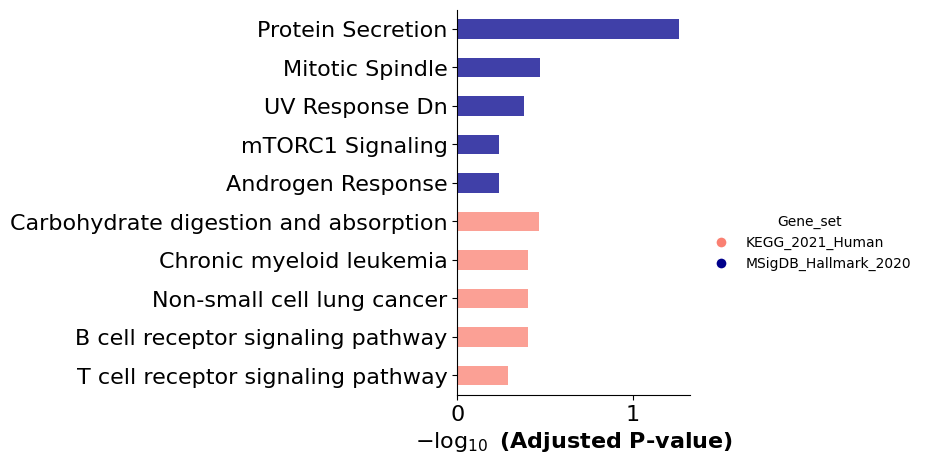

2025-11-24 14:41:51 - INFO - Input contains 149225 features, now perform filtering with 'min_log_fc = 0.25' and 'min_pct = 0.01' ...


✓ GO enrichment plot saved: go_enrichment_NK cell_G-3243-A.png
Number of matches (True): 83
Number of non-matches (False): 3718
Value counts:
 CD8 T cell_3243_status
False    3718
True       83
Name: count, dtype: int64
Number of matches (True): 656
Number of non-matches (False): 3145
Value counts:
 CD8 T cell_3243_status
False    3145
True      656
Name: count, dtype: int64
Overlap: 0


2025-11-24 14:41:54 - INFO - Testing 57876 features ...
100%|██████████| 57876/57876 [02:38<00:00, 364.36it/s]


Total unique genes: 64
Gene list: ['ENSG00000259827', 'ENSG00000287958', 'PLEKHG1', 'ENSG00000234084', 'ZNF44', 'SHOC2', 'SLC25A38', 'AHI1', 'LINC02579', 'ANKS1B', 'ENSG00000225649', 'WIPF1', 'ENSG00000287780', 'SEC24B-AS1', 'ENSG00000227240', 'MARK2', 'SNHG10', 'TNNC2', 'PPP1R35-AS1', 'PLOD1', 'KDSR', 'ENSG00000236449', 'TPRG1', 'INPP4B', 'NEK7', 'CCSER2', 'IGHV4-39', 'MT1X', 'ENSG00000283064', 'PPP1R35', 'GATA3', 'DOCK7', 'IL2RA', 'ZNF326', 'TNFAIP8', 'ATXN1', 'MYO3B', 'H2BC6', 'PPP2R5E', 'PBDC1', 'CCDC91', 'ENSG00000284606', 'AFAP1', 'GLRX5', 'DUSP15', 'CYFIP2', 'ASB13', 'MYH9', 'UMODL1', 'SEMA6C', 'CKAP4', 'ENSG00000234378', 'ENSG00000285868', 'AAK1', 'CCNT2', 'ZCCHC7', 'CCNT2-AS1', 'DNAJC17', 'CIB4', 'EVI5', 'GCHFR', 'YEATS2', 'ENSG00000241357', 'FNDC9']

Gene list saved to 'differential_peaks_genes_CD8 T cell_G-3243-A.txt'
Finished annotating genes for  CD8 T cell


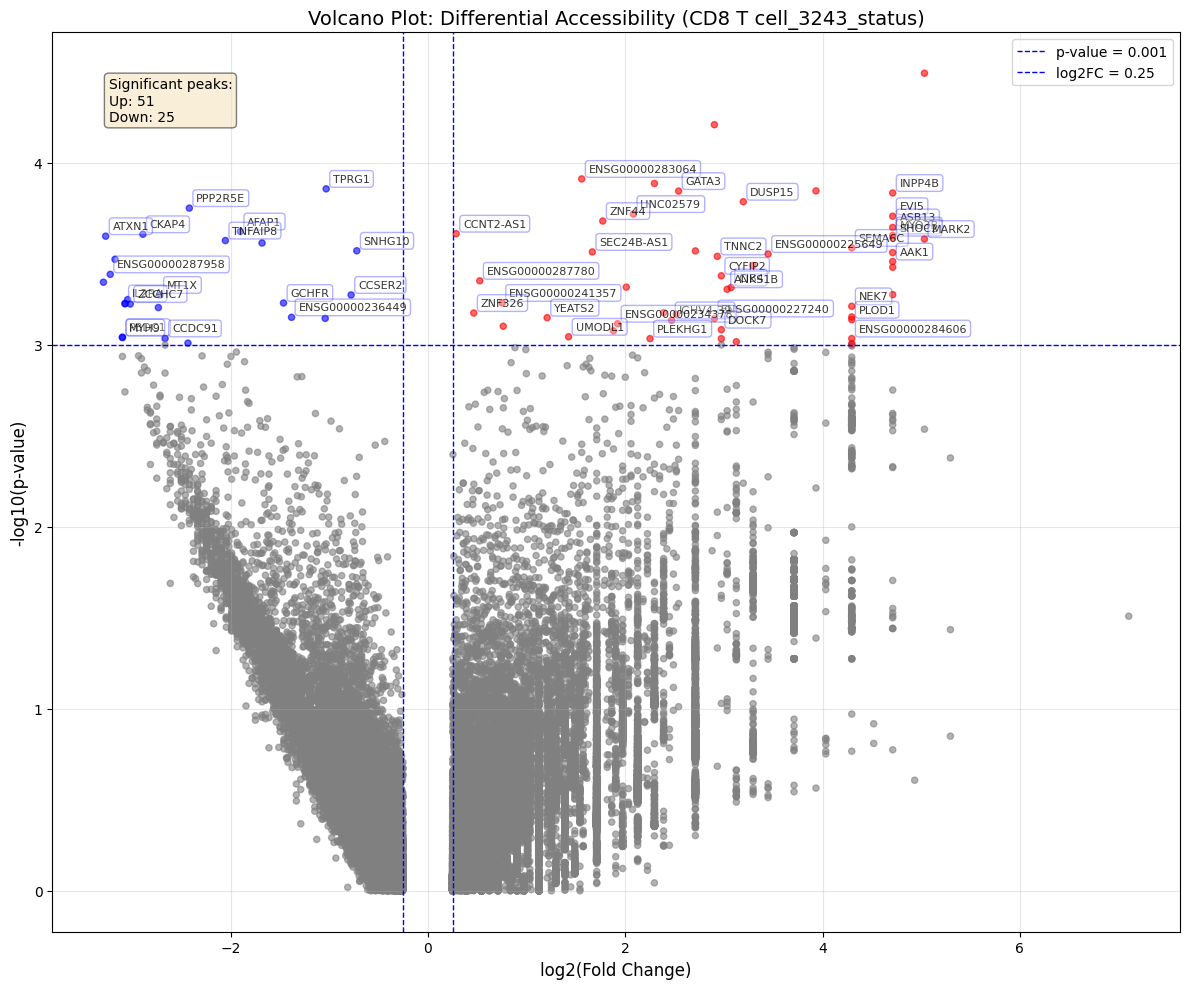

Volcano plot saved for  CD8 T cell


/Users/lucascortes/miniconda3/lib/python3.13/site-packages/gseapy/plot.py:753: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/folders/xk/48p4vmnj5z1g941ty5p14nbc0000gq/T/ipykernel_53812/1976349211.py:26: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



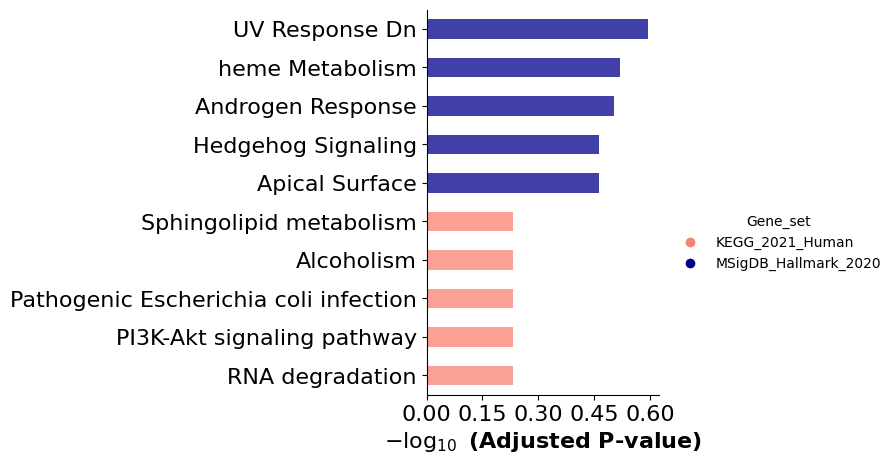

✓ GO enrichment plot saved: go_enrichment_CD8 T cell_G-3243-A.png


In [58]:
differential_expression_by_cell_type(WBC048, mgatk, peak_mat, "G-3243-A", upper_VAF=0.1, lower_VAF=0.00)

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get VAF matrix and variant of interest
variant_name = "G-3243-A"
variant_names = mgatk.uns['variant_names']
variant_idx = mgatk.uns['variant_names'].index(variant_name)
vaf_matrix = mgatk.obsm['variant_vaf_high_quality']
vaf_values_3243 = vaf_matrix[:, variant_idx]

# Calculate correlations between 3243 and all other variants
correlations = []
for i, other_variant in enumerate(variant_names):
    if i == variant_idx:
        continue
    
    other_vaf = vaf_matrix[:, i]
    
    # Only calculate correlation if both variants have some non-zero values
    if (other_vaf > 0).sum() > 5 and (vaf_values_3243 > 0).sum() > 5:
        # Calculate Pearson correlation
        corr = np.corrcoef(vaf_values_3243, other_vaf)[0, 1]
        
        # Calculate overlap: cells expressing both variants
        both_expressed = ((vaf_values_3243 > 0.1) & (other_vaf > 0.1)).sum()
        only_3243 = ((vaf_values_3243 > 0.1) & (other_vaf <= 0.1)).sum()
        only_other = ((vaf_values_3243 <= 0.1) & (other_vaf > 0.1)).sum()
        
        correlations.append({
            'variant': other_variant,
            'correlation': corr,
            'both_expressed': both_expressed,
            'only_3243': only_3243,
            'only_other': only_other,
            'cells_with_other': (other_vaf > 0.1).sum()
        })

# Create DataFrame and sort by correlation
corr_df = pd.DataFrame(correlations)
corr_df = corr_df.sort_values('correlation', ascending=False)

# Display top co-segregating variants
print("=== TOP 20 VARIANTS POSITIVELY CORRELATED WITH G-3243-A ===")
print(corr_df.head(20))

print("\n=== TOP 20 VARIANTS NEGATIVELY CORRELATED WITH G-3243-A ===")
print(corr_df.tail(20))


# Filter for highly correlated variants (correlation > 0.5)
high_corr_variants = corr_df[corr_df['correlation'] > 0.5]
print(f"\n=== {len(high_corr_variants)} VARIANTS WITH CORRELATION > 0.5 ===")
print(high_corr_variants)



=== TOP 20 VARIANTS POSITIVELY CORRELATED WITH G-3243-A ===
      variant  correlation  both_expressed  only_3243  only_other  \
34  G-15326-A     0.108852             473          5        2924   
35    G-750-A     0.104599             474          4        2943   
19   A-9912-G     0.098110               6        472           2   
32  G-13434-A     0.087438               6        472           2   
5   C-16519-T     0.085081             451         27        2787   
42  G-14193-A     0.073183             432         46        2662   
4   C-16172-T     0.071724              13        465           7   
11   C-2159-T     0.066370             438         40        2737   
39   G-1438-A     0.060109             409         69        2579   
29   A-6657-G     0.054923               4        474           1   
33    G-772-A     0.051580              10        468           3   
38   G-4136-A     0.044265               9        469           4   
6    C-3109-T     0.035008              10 

In [60]:
# Select top correlated variants for visualization
top_variants = corr_df.head(10)['variant'].tolist()
top_variant_indices = [np.where(variant_names == v)[0][0] for v in top_variants]

# Add 3243 to the list
all_indices = [variant_idx] + top_variant_indices
selected_vaf = vaf_matrix[:, all_indices]
selected_names = [variant_name] + top_variants

# Create binary matrix (expressed vs not expressed)
binary_matrix = (selected_vaf > 0.1).astype(int)

# Calculate pairwise correlations
corr_matrix = np.corrcoef(binary_matrix.T)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            xticklabels=selected_names,
            yticklabels=selected_names,
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            annot=True,
            fmt='.2f',
            square=True)
plt.title('Variant Co-occurrence Correlation Matrix')
plt.tight_layout()
plt.show()

/var/folders/xk/48p4vmnj5z1g941ty5p14nbc0000gq/T/ipykernel_53812/2078668225.py:3: DeprecationWarning:

Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.



IndexError: index 0 is out of bounds for axis 0 with size 0

In [63]:
## Generate data for circos plot of variant VAF per position 
import re

position_vaf = {}
for i, variant in enumerate(variant_names):
    if i == variant_idx:
        continue
    var_len = len(variant)

    position = re.sub(r'[GACTN-]', '', variant)
    #print(position)
    vaf = vaf_matrix[:, i]
    mean_vaf = np.nanmean(vaf[vaf > 0]) if (vaf > 0).any() else 0.0
    position_vaf[position] = mean_vaf
#print(position_vaf)
#print(list(position_vaf)[0])
VAFs= list(position_vaf.values())
for i in range(len(VAFs)):
    if VAFs[i] > 1.0:
        print(VAFs[i])
#print(list(position_vaf.keys()))

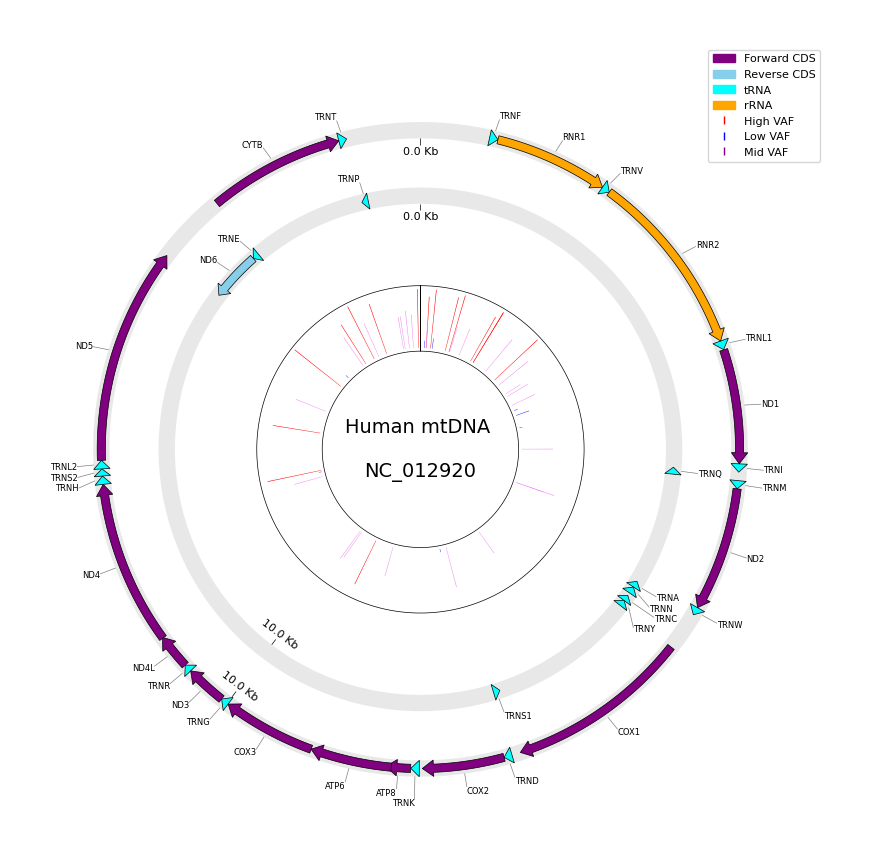

In [64]:
from pycirclize import Circos
from pycirclize.utils import fetch_genbank_by_accid
from pycirclize.parser import Genbank
from itertools import chain
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Download mito genome 
gbk_fetch_data = fetch_genbank_by_accid("NC_012920.1")
gbk = Genbank(gbk_fetch_data)

# Initialize Circos instance with genome size
sectors = gbk.get_seqid2size()
space = 0 if len(sectors) == 1 else 2
circos = Circos(sectors, space=space)
circos.text(f"Human mtDNA \n\n{gbk.name}", size=14)
features = ["tRNA", "rRNA", "CDS", "D-loop gene"]
seqid2features = []
for feature in range(len(features)):
    seqid2features.append(gbk.get_seqid2features(features[feature]))

#seqid2features = gbk.get_seqid2features(feature_type="CDS")
#print(seqid2features)
for sector in circos.sectors:
    ## X and Y are the x positions and y values for barplot
    x = list(position_vaf.keys())
    x = [ int(x) for x in x ]
    y = list(position_vaf.values())
    y = [ float(y) for y in y ]  
    # Setup track for features plot
    f_cds_track = sector.add_track((95, 100))
    f_cds_track.axis(fc="lightgrey", ec="none", alpha=0.5)
    r_cds_track = sector.add_track((75, 80))
    r_cds_track.axis(fc="lightgrey", ec="none", alpha=0.5)
    # Plot forward/reverse strand CDS
    for type in range(len(features)):

        features = seqid2features[type][sector.name]
        for feature in features:
            if feature.location.strand == 1 and feature.type == "CDS":
                f_cds_track.genomic_features(feature, plotstyle="arrow", fc="purple", lw=0.5)
            elif feature.location.strand == -1 and feature.type == "rRNA":
                r_cds_track.genomic_features(feature, plotstyle="arrow", fc="orange", lw=0.5)
            elif feature.location.strand == -1 and feature.type == "tRNA":
                r_cds_track.genomic_features(feature, plotstyle="arrow", fc="aqua", lw=0.5)
            elif feature.location.strand == 1 and feature.type == "rRNA":
                f_cds_track.genomic_features(feature, plotstyle="arrow", fc="orange", lw=0.5)
            elif feature.location.strand == 1 and feature.type == "tRNA":
                f_cds_track.genomic_features(feature, plotstyle="arrow", fc="aqua", lw=0.5)
            else:
                r_cds_track.genomic_features(feature, plotstyle="arrow", fc="skyblue", lw=0.5)

        # Plot 'gene' qualifier label if exists
        labels, label_pos_list = [], []
        for feature in features:
            start = int(feature.location.start)
            end = int(feature.location.end)
            label_pos = (start + end) / 2
            gene_name = feature.qualifiers.get("gene",[None])[0]
            
            if gene_name is not None and feature.location.strand == 1:
                labels.append(gene_name)
                label_pos_list.append(label_pos)
                f_cds_track.annotate(label_pos, gene_name, label_size=6)
            elif gene_name is not None and feature.location.strand == -1:
                labels.append(gene_name)
                label_pos_list.append(label_pos)
                r_cds_track.annotate(label_pos, gene_name, label_size=6)

    # Plot xticks (interval = 10 Kb)
    r_cds_track.xticks_by_interval(
        10000, outer=False, label_formatter=lambda v: f"{v/1000:.1f} Kb"
    )
    f_cds_track.xticks_by_interval(
        10000, outer=False, label_formatter=lambda v: f"{v/1000:.1f} Kb"
    )
    barplot_track = sector.add_track((30, 50), r_pad_ratio=0.1)
    barplot_track.axis()

    # Convert to numpy arrays
    x_array = np.array(x)
    y_array = np.array(y)

    # Split into two groups based on VAF threshold
    above_threshold = y_array >= 0.75
    below_threshold = y_array < 0.25
    mid_threshold = (y_array >= 0.25) & (y_array < 0.75)

    # Plot bars in different colors based on threshold
    if above_threshold.any():
        barplot_track.bar(x_array[above_threshold], y_array[above_threshold], color="red", vmin=0, vmax=1, width=10)
    if below_threshold.any():
        barplot_track.bar(x_array[below_threshold], y_array[below_threshold], color="blue", vmin=0, vmax=1, width=10)
    if mid_threshold.any():
        barplot_track.bar(x_array[mid_threshold], y_array[mid_threshold], color="violet", vmin=0, vmax=1, width=10)

    


fig = circos.plotfig()

# Add legend
handles = [
    Patch(color="purple", label="Forward CDS"),
    Patch(color="skyblue", label="Reverse CDS"),
    Patch(color="aqua", label="tRNA"),
    Patch(color="orange", label="rRNA"),
    Line2D([], [], color="red", label="High VAF", marker="|", ms=6, ls="None"),
    Line2D([], [], color="blue", label="Low VAF", marker="|", ms=6, ls="None"),
    Line2D([], [], color="purple", label="Mid VAF", marker="|", ms=6, ls="None"),

]
_ = circos.ax.legend(handles=handles, bbox_to_anchor=(1, 1), loc="center", fontsize=8)

# Save using fig.savefig() instead of circos.savefig()
fig.savefig("mtDNA_variantVAF.svg", bbox_inches='tight')


In [65]:
## Generate data for circos plot of variant VAF per position 
import re

position_vaf = {}
for i, variant in enumerate(variant_names):
    if i == variant_idx:
        continue
    var_len = len(variant)

    position = re.sub(r'[GACTN-]', '', variant)
    #print(position)
    vaf = vaf_matrix[:, i]
    counts = np.sum(vaf > 0) if (vaf > 0).any() else 0.0
    
    position_vaf[position] = counts

#print(position_vaf)

print(list(position_vaf)[0])
print(len(list(position_vaf.values())))
print(len(list(position_vaf.keys())))
VAFs= list(position_vaf.values())
print(VAFs)
max(VAFs)

10170
6000
6000
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 34, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 14, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 19, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 30, 0.

3417

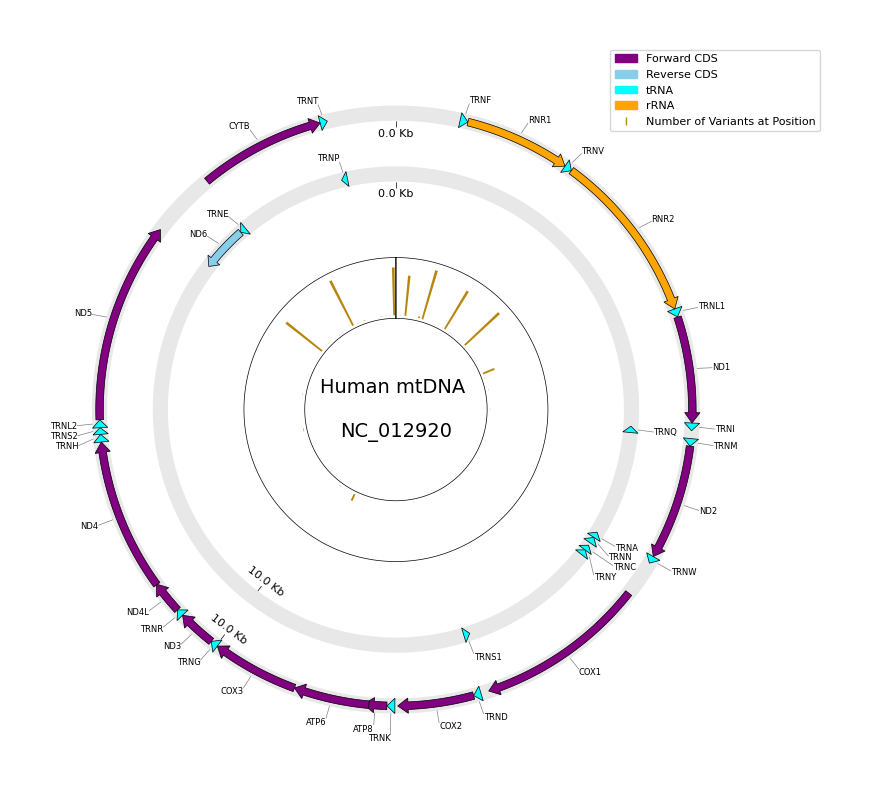

In [66]:
from pycirclize import Circos
from pycirclize.utils import fetch_genbank_by_accid
from pycirclize.parser import Genbank
from itertools import chain

# Download mito genome
gbk_fetch_data = fetch_genbank_by_accid("NC_012920.1")
gbk = Genbank(gbk_fetch_data)

# Initialize Circos instance with genome size
sectors = gbk.get_seqid2size()
space = 0 if len(sectors) == 1 else 2
circos = Circos(sectors, space=space)
circos.text(f"Human mtDNA \n\n{gbk.name}", size=14)
features = ["tRNA", "rRNA", "CDS", "D-loop gene"]
seqid2features = []
for feature in range(len(features)):
    seqid2features.append(gbk.get_seqid2features(features[feature]))

#seqid2features = gbk.get_seqid2features(feature_type="CDS")
#print(seqid2features)
for sector in circos.sectors:
    ## X and Y are the x positions and y values for barplot
    x = list(position_vaf.keys())
    x = [ int(x) for x in x ]
    y = list(position_vaf.values())
    y = [ int(y) for y in y ] 
    # Setup track for features plot
    f_cds_track = sector.add_track((95, 100))
    f_cds_track.axis(fc="lightgrey", ec="none", alpha=0.5)
    r_cds_track = sector.add_track((75, 80))
    r_cds_track.axis(fc="lightgrey", ec="none", alpha=0.5)
    # Plot forward/reverse strand CDS
    for type in range(len(features)):

        features = seqid2features[type][sector.name]
        for feature in features:
            if feature.location.strand == 1 and feature.type == "CDS":
                f_cds_track.genomic_features(feature, plotstyle="arrow", fc="purple", lw=0.5)
            elif feature.location.strand == -1 and feature.type == "rRNA":
                r_cds_track.genomic_features(feature, plotstyle="arrow", fc="orange", lw=0.5)
            elif feature.location.strand == -1 and feature.type == "tRNA":
                r_cds_track.genomic_features(feature, plotstyle="arrow", fc="aqua", lw=0.5)
            elif feature.location.strand == 1 and feature.type == "rRNA":
                f_cds_track.genomic_features(feature, plotstyle="arrow", fc="orange", lw=0.5)
            elif feature.location.strand == 1 and feature.type == "tRNA":
                f_cds_track.genomic_features(feature, plotstyle="arrow", fc="aqua", lw=0.5)
            else:
                r_cds_track.genomic_features(feature, plotstyle="arrow", fc="skyblue", lw=0.5)

        # Plot 'gene' qualifier label if exists
        labels, label_pos_list = [], []
        for feature in features:
            start = int(feature.location.start)
            end = int(feature.location.end)
            label_pos = (start + end) / 2
            gene_name = feature.qualifiers.get("gene",[None])[0]
            
            if gene_name is not None and feature.location.strand == 1:
                labels.append(gene_name)
                label_pos_list.append(label_pos)
                f_cds_track.annotate(label_pos, gene_name, label_size=6)
            elif gene_name is not None and feature.location.strand == -1:
                labels.append(gene_name)
                label_pos_list.append(label_pos)
                r_cds_track.annotate(label_pos, gene_name, label_size=6)
    
    # Plot xticks (interval = 10 Kb)
    r_cds_track.xticks_by_interval(
        10000, outer=False, label_formatter=lambda v: f"{v/1000:.1f} Kb"
    )
    f_cds_track.xticks_by_interval(
        10000, outer=False, label_formatter=lambda v: f"{v/1000:.1f} Kb"
    )
    barplot_track = sector.add_track((30, 50), r_pad_ratio=0.1)

    # Plot bars in different colors based on threshold
    barplot_track.axis()
    barplot_track.bar(x, y, vmax = 3700, color="darkgoldenrod", width = 50)

    


fig = circos.plotfig()

# Add legend
handles = [
    Patch(color="purple", label="Forward CDS"),
    Patch(color="skyblue", label="Reverse CDS"),
    Patch(color="aqua", label="tRNA"),
    Patch(color="orange", label="rRNA"),
    Line2D([], [], color="darkgoldenrod", label="Number of Variants at Position", marker="|", ms=6, ls="None"),

]
_ = circos.ax.legend(handles=handles, bbox_to_anchor=(1, 1), loc="center", fontsize=8)
fig.savefig("mtDNA_variantNumber.svg")


In [67]:
## Testing clonotyping on filtered variants (49) in order to check feasibility for MERLIN 
from Py_mTCall_tools import clonotype_analysis

After sufficient_coverage: 6600 variants remaining
After strand_concordance: 6593 variants remaining
After low_variance: 6593 variants remaining

Final selection: Using 6593 high-confidence variants for clonotype analysis
Filtering criteria applied:
  - Confidently detected in >= 1 cells
  - VAF >= 0.1 in >= 1 cells
  - Mean coverage >= 10x
  - Strand concordance >= 0.3 (or single-strand)
  - VAF variance <= 1


/Users/lucascortes/miniconda3/lib/python3.13/site-packages/anndata/_core/anndata.py:865: UserWarning:


AnnData expects .var.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer


/Users/lucascortes/miniconda3/lib/python3.13/site-packages/anndata/_core/anndata.py:865: UserWarning:


AnnData expects .var.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer


/Users/lucascortes/miniconda3/lib/python3.13/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning:

Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.

/Users/lucascortes/miniconda3/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.

/Users/lucascortes/Library/CloudStorage/OneDrive-Personal/Documents/Work/P

Identified 57 clonotypes
Clonotype sizes: {'clonotype_30': 461, 'clonotype_37': 365, 'clonotype_41': 208, 'clonotype_29': 192, 'clonotype_11': 173, 'clonotype_13': 168, 'clonotype_49': 163, 'clonotype_34': 152, 'clonotype_21': 150, 'clonotype_25': 127, 'clonotype_6': 122, 'clonotype_42': 120, 'clonotype_56': 118, 'clonotype_3': 99, 'clonotype_53': 98, 'clonotype_40': 93, 'clonotype_7': 89, 'clonotype_46': 81, 'clonotype_31': 77, 'clonotype_12': 76, 'clonotype_4': 69, 'clonotype_43': 66, 'clonotype_52': 61, 'clonotype_39': 55, 'clonotype_22': 45, 'clonotype_45': 36, 'clonotype_0': 33, 'clonotype_55': 31, 'clonotype_28': 26, 'clonotype_26': 20, 'clonotype_20': 20, 'clonotype_51': 19, 'clonotype_35': 17, 'clonotype_36': 15, 'clonotype_23': 15, 'clonotype_10': 10, 'clonotype_48': 10, 'clonotype_32': 9, 'clonotype_27': 8, 'clonotype_15': 8, 'clonotype_24': 8, 'clonotype_50': 7, 'clonotype_5': 7, 'clonotype_54': 7, 'clonotype_8': 7, 'clonotype_2': 6, 'clonotype_38': 6, 'clonotype_16': 6, 'cl

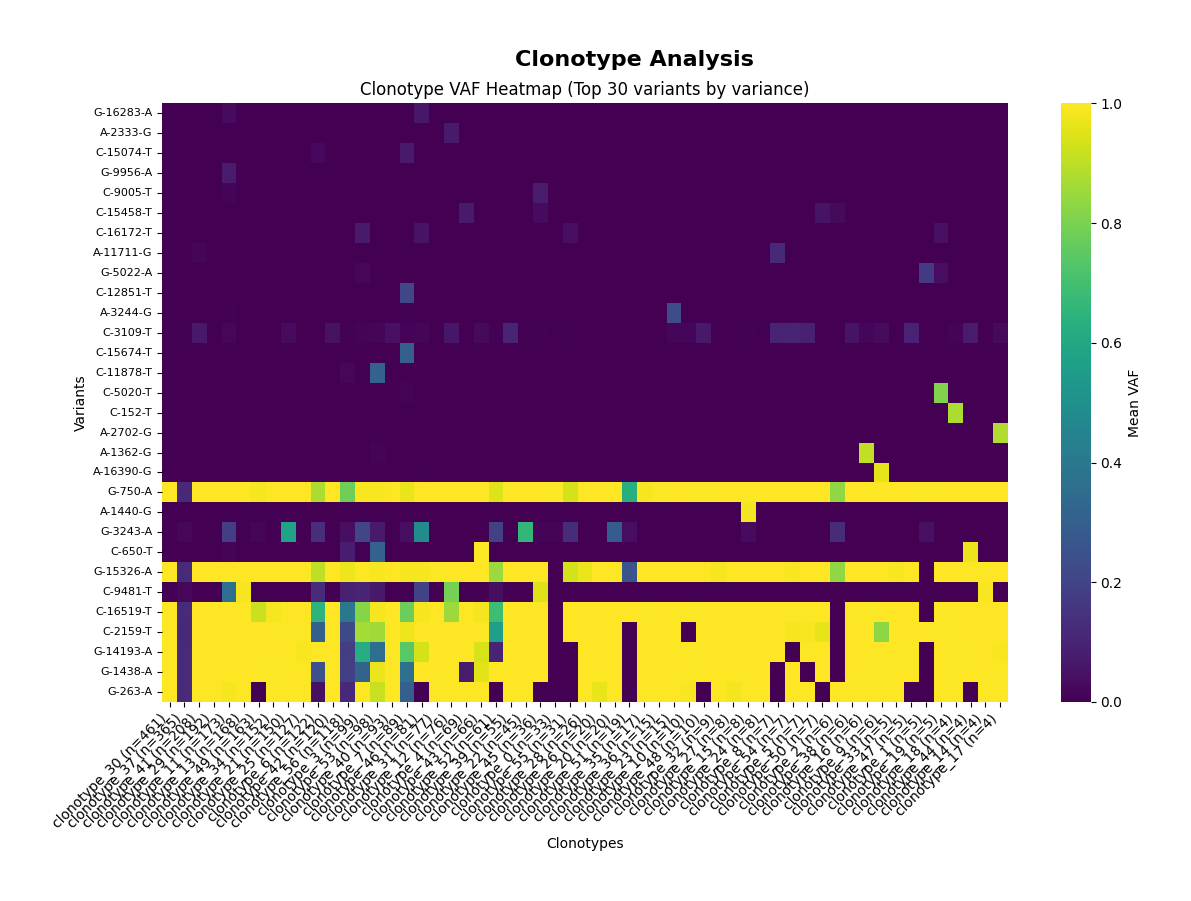

In [68]:
# Run clonotype analysis on PTPRC- cells
mgatk.obsm['variant_vaf_high_quality_matrix'] = mgatk.obsm['variant_vaf_high_quality']

mgatk_clonotypes= clonotype_analysis.analyze_clonotypes_from_variants(
    mgatk,
    vaf_layer_name="variant_vaf_high_quality",
    resolution=0.2,
    min_vaf=0.1,
    min_coverage=10,
    k=5
)

# Create heatmap for clonotypes

fig_neg = clonotype_analysis.plot_clonotype_vaf_heatmap(
    mgatk_clonotypes,
    vaf_layer_name="variant_vaf_high_quality",
    clonotype_col="clonotype_leiden",
    top_variants=30,
    figsize=(12, 8)
)

# Adjust colormap
for ax in fig_neg.get_axes():
    images = ax.get_images()
    if images:
        images[0].set_cmap('plasma')
        from matplotlib.colors import PowerNorm
        images[0].set_norm(PowerNorm(gamma=0.5))
        break

fig_neg.suptitle('Clonotype Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.show()





In [69]:
##Export high quality variants to CSV
# Get high quality variants from the filtered matrix
vaf_matrix = mgatk.obsm['variant_vaf_high_quality']
variant_names = mgatk.uns['variant_names']

# Find variants that have at least one cell with expression
variants_with_expression = []

for i, variant_name in enumerate(variant_names):
    if (vaf_matrix[:, i] > 0).any():  # Check if any cell has this variant
        # Parse variant name (format: "alt-pos-ref")
        parts = variant_name.split('-')
        if len(parts) == 3:
            alt, pos, ref = parts
            variants_with_expression.append({
                'chr': 'MT',
                'sample': 'WBC048',
                'pos': int(pos),
                'ref': ref,
                'alt': alt
                
            })

# Create DataFrame and save to CSV
variants_df = pd.DataFrame(variants_with_expression)
variants_df = variants_df.sort_values('pos')  # Sort by position

# Save to CSV
variants_df.to_csv('WBC048_variants.csv', index=False)